# Lecture 10: Direct Method III, Collocation

Lecture 9 ended with multiple shooting: more arcs give more local defects, more
sparsity, and less integration per arc. **Collocation** uses the related idea of
local dynamic constraints, but with *no integrator at all*. The state is
represented directly as a **piecewise polynomial**, selected state-node values
become design variables (the exact subset depends on the transcription), and
the dynamics are imposed as **defect constraints** that
require the polynomial to satisfy the ODE at selected *collocation points*.

**Roadmap**

1. **Nodes and basis functions**: Gauss, Lobatto and Radau nodes; Lagrange
   and Hermite bases
2. **The brachistochrone, collocated**: the recipe, the NLP it produces, the
   solution, the defects closing during the solve, what a zero defect does
   and does not guarantee, and an interactive study of order and node family
3. **The total Jacobian**: sparse and banded, and convergence on a smooth
   problem
4. **Discontinuous controls**: automatic grid refinement on the minimum-time
   double integrator
5. **The SSTO launch, revisited**: the Lecture 9 capstone under collocation
6. **The minimum-time climb, revisited**: notebook 02's grid without the
   per-segment integration

## Recap: collocation as an NLP

The continuous optimal control problem

$$
\min_{u(\cdot),\,t_f} \; J = \phi\big(x(t_f), t_f\big)
\qquad \text{s.t.} \quad \dot{x} = f(x, u, t), \quad x(t_0) = x_0, \quad
\psi\big(x(t_f)\big) = 0, \quad u \in \mathcal{U}
$$

is transcribed by:

1. **Choosing a grid** of $K$ segments on $[t_0, t_f]$ and representing
   *both* the state and the control on every segment as polynomials through
   a set of nodes, with the nodal values as parameters: the control's nodal
   values $U$, the same control parameter vector as in Lecture 9, and now
   also the state's nodal values $X$, which shooting eliminated by
   integration (notebook 02's arc initial states $s_i$ were the subset of
   $X$ at the arc boundaries). The design vector is $z = (t_f, X, U)$.
2. **Imposing the dynamics at the collocation points** $\tau_k$ of every
   segment, one algebraic equation per collocation point per state:
   $\Delta_k = \dot{x}_{\text{poly}}(\tau_k) - f\big(x(\tau_k), u(\tau_k)\big) = 0$.
   Evaluating $\Delta$ needs no integration: it is the polynomial's slope
   minus the ODE's right-hand side.
3. **Boundary conditions act directly on nodal quantities**: because $x(t_f)$
   is available algebraically, a prescribed terminal state can be imposed by
   fixing that design variable (`fix_final=True`). More general endpoint
   conditions are still expressed as boundary constraints.
4. **Handing the optimizer** the NLP

$$
\min_{z} \; \phi\big(x_N, t_f\big) \qquad \text{s.t.} \quad
\Delta(z) = 0, \quad \text{continuity}, \quad z_L \le z \le z_U .
$$

Three consequences follow, each demonstrated below: a function evaluation
is $f$ at the nodes and the Jacobian is cheap and **sparse** (section 3);
**iterates are not generally trajectories**, because until the defects converge
the polynomial is not required to satisfy the dynamics at the collocation
points, so the initial guess need not be a trajectory at all (section 2); and
the discretization error is **local**
and can be estimated per segment, which enables automatic grid refinement
(section 4).

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator
from numpy.polynomial.legendre import leggauss
from scipy.interpolate import lagrange
from scipy.optimize import fsolve
import ipywidgets as widgets
from IPython.display import HTML, display

warnings.filterwarnings('ignore', message='.*INF_BOUND.*')

import openmdao
import openmdao.api as om
from openmdao.utils.om_warnings import OpenMDAOWarning, DerivativesWarning

warnings.filterwarnings('ignore', category=OpenMDAOWarning)
warnings.filterwarnings('ignore', category=DerivativesWarning)

import dymos as dm
from dymos.utils.lgl import lgl
from dymos.utils.lgr import lgr

from oclectures import (apply_style, describe_nlp, total_jacobian, plot_jacobian,
                        symbol_labels, quiet, redirect_outputs_to_tmp, COLORS)

apply_style()
redirect_outputs_to_tmp()  # keep OpenMDAO's problemN_out/ folders out of this directory
print(f'dymos {dm.__version__}, OpenMDAO {openmdao.__version__}')

dymos 1.15.1, OpenMDAO 3.45.1


---
## 1. Nodes and basis functions

Every segment is mapped to the reference interval $\tau \in [-1, 1]$, and the
polynomials on it are defined by their values at a set of **nodes**. The
node families in common use are all built from the **Legendre polynomials**
$P_n$, the polynomials that are mutually orthogonal on $[-1, 1]$:
$P_0 = 1$, $P_1 = \tau$, $P_2 = \tfrac12(3\tau^2 - 1)$,
$P_3 = \tfrac12(5\tau^3 - 3\tau)$, and so on. Their roots are the nodes
of Gaussian quadrature: $n$ points placed at the roots of $P_n$ integrate
every polynomial of degree up to $2n - 1$ exactly, the most any $n$ points
can achieve, and a collocation scheme at such nodes inherits that accuracy
(the Hermite–Simpson defect below *is* Simpson's rule for this reason). The
three families differ only in whether they include the segment endpoints,
giving up one or two degrees of exactness so that adjacent segments can
share a node:

- **Gauss** (LG): interior nodes only, the roots of $P_n$. At order 3,
  $P_3 = 0$ gives $\tau = 0, \pm\sqrt{3/5}$.
- **Lobatto** (LGL): both endpoints plus the roots of $P_{n-1}'$. At order 3,
  $P_2' = 3\tau$ gives $\tau = -1, 0, 1$: the Hermite–Simpson midpoint.
- **Radau** (LGR): one endpoint plus the roots of $P_{n-1} + P_n$. At order 3,
  $P_2 + P_3 = \tfrac12 (\tau + 1)(5\tau^2 - 2\tau - 1)$ gives
  $\tau = -1, -0.290, 0.690$.

In the chart, filled markers are **collocation points**, nodes where a
defect is imposed, in the classical pseudospectral methods: Gauss and
Lobatto collocate at every node, Radau at the LGR nodes only. The hollow
marker on each Radau row is the appended right endpoint, which carries a
state value so that adjacent segments can share a node, but no defect.

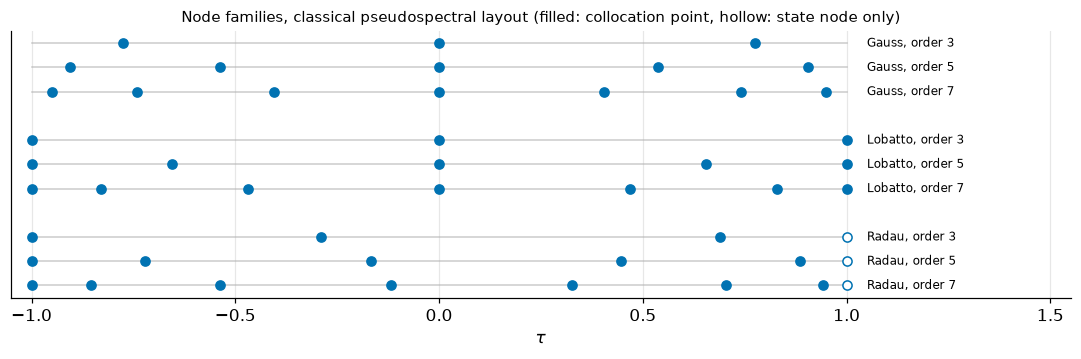

In [2]:
def nodes(family, n):
    '''Nodes on [-1, 1] and a mask of which are collocation points.'''
    if family == 'Gauss':
        x, _ = leggauss(n)
        return x, np.ones(n, bool)
    if family == 'Lobatto':
        x, _ = lgl(n)
        return x, np.ones(n, bool)
    if family == 'Radau':
        x, _ = lgr(n, include_endpoint=True)
        is_col = np.ones(len(x), bool)
        is_col[-1] = False  # the appended endpoint is not collocated
        return x, is_col


fig, ax = plt.subplots(figsize=(10, 3.4))
for i, family in enumerate(['Gauss', 'Lobatto', 'Radau']):
    for j, n in enumerate([3, 5, 7]):
        x, is_col = nodes(family, n)
        row = -(4 * i + j)
        ax.plot([-1, 1], [row, row], color='0.8', lw=1, zorder=0)
        ax.plot(x[is_col], row * np.ones(is_col.sum()), 'o', ms=6,
                color=COLORS['dymos'])
        ax.plot(x[~is_col], row * np.ones((~is_col).sum()), 'o', ms=6,
                mfc='white', color=COLORS['dymos'])
        ax.text(1.05, row, f'{family}, order {n}', va='center', fontsize=8)
ax.set_xlim(-1.05, 1.55); ax.set_yticks([]); ax.set_xlabel(r'$\tau$')
ax.set_title('Node families, classical pseudospectral layout (filled: collocation point, hollow: state node only)',
             fontsize=10)
fig.tight_layout()

The polynomial through $n$ nodes is written in the **Lagrange basis**: the
cardinal polynomials $\ell_j(\tau)$ with $\ell_j(\tau_i) = \delta_{ij}$, so
that $x(\tau) = \sum_j x_j \,\ell_j(\tau)$ and the nodal values $x_j$ are the
design variables directly. In the classical pseudospectral methods the state
and the control are both such interpolants through all of a segment's nodes,
and the defects are imposed at the filled nodes of the chart. Why
Legendre-type nodes rather than equally spaced ones: as the order grows, these
nodes cluster toward the segment ends and keep interpolation growth far better
controlled (their Lebesgue constants grow much more slowly). Individual
cardinal functions are not generally bounded by one. With equally spaced nodes
the interpolation operator grows rapidly near the ends, producing the Runge
phenomenon and oscillation between nodes.

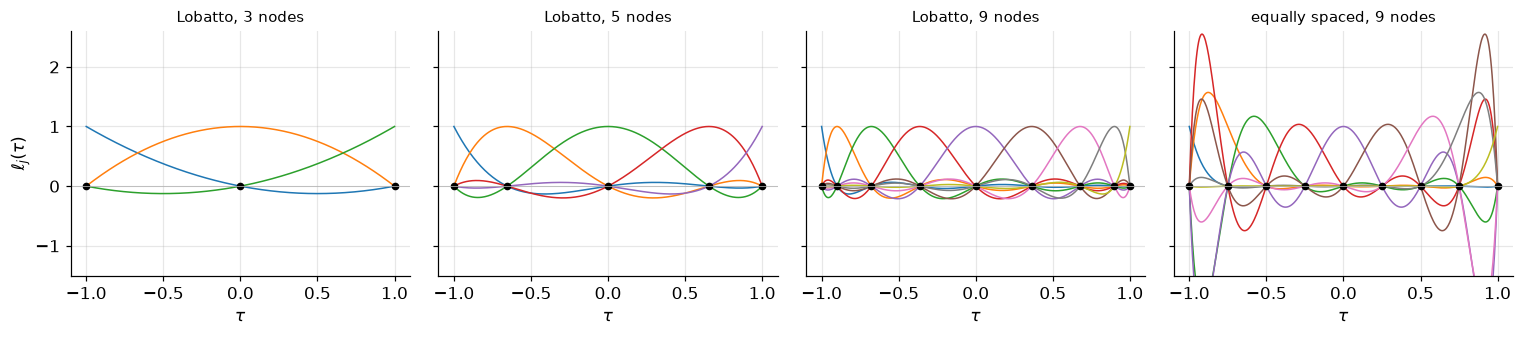

In [3]:
def lagrange_basis(x_nodes, tau):
    L = np.ones((len(x_nodes), len(tau)))
    for j, xj in enumerate(x_nodes):
        for m, xm in enumerate(x_nodes):
            if m != j:
                L[j] *= (tau - xm) / (xj - xm)
    return L


tau = np.linspace(-1, 1, 400)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, (family, n) in zip(axes, [('Lobatto', 3), ('Lobatto', 5), ('Lobatto', 9),
                                  ('equally spaced', 9)]):
    x_nodes = np.linspace(-1, 1, n) if family == 'equally spaced' else nodes(family, n)[0]
    for L_j in lagrange_basis(x_nodes, tau):
        ax.plot(tau, L_j, lw=1)
    ax.plot(x_nodes, np.zeros(n), 'o', ms=4, color='k')
    ax.axhline(0, color='0.7', lw=0.5)
    ax.set_title(f'{family}, {n} nodes', fontsize=10); ax.set_xlabel(r'$\tau$')
axes[0].set_ylabel(r'$\ell_j(\tau)$'); axes[0].set_ylim(-1.5, 2.6)
fig.tight_layout()

dymos offers two transcriptions built on these nodes. They share the same
rule, the slope of the state polynomial must equal the dynamics at every
collocation point, and differ in what defines that polynomial.

**Gauss–Lobatto** (Hermite–Simpson and its higher-order generalization) is
where dymos departs from the classical layout above. It uses LGL nodes of odd
order but splits them into two alternating sets. The state
is a design variable only at every other node, both ends included. At those
nodes the ODE is evaluated to obtain the rates, and the values together with
the rates define a **Hermite** interpolant. The defects are enforced at the remaining nodes in
between, where the state is interpolated rather than solved for. At order 3
this is Hermite–Simpson: states at the segment ends, one defect at the
midpoint, equivalent to Simpson's rule.

**Radau** (pseudospectral) follows the classical layout: the LGR nodes plus
the segment's right endpoint, and every node carries a state variable. The state is the
**Lagrange** interpolant of those values alone, and the defects are enforced
at the LGR nodes; the right endpoint is not collocated, it is the node shared
with the next segment.

The difference is therefore which data define the polynomial: values and ODE
rates in Gauss–Lobatto, values only in Radau. Gauss–Lobatto needs fewer state
variables per segment, but it evaluates the ODE twice per segment (at the
state nodes, then at the collocation nodes) and interpolates the state in
between, so state bounds act only at the state nodes. Radau has the same
structure at every order, every node a variable and the ODE evaluated once,
and is the more common default at high order. Radau accepts any order
$\ge 3$, Gauss–Lobatto odd orders only.

**The control** on each segment is a Lagrange polynomial through its control
nodes, all nodes in Gauss–Lobatto and the LGR nodes in Radau; it is evaluated
wherever the dynamics are and has no defect of its own. Adjacent control
pieces are joined either by a shared boundary node (Gauss–Lobatto on a
compressed grid) or by explicit continuity constraints (Radau, whose control
nodes exclude the right endpoint), optionally with matched slopes
(`rate_continuity`).

---
## 2. The brachistochrone, collocated

The same problem as notebooks 01/02: a bead slides without friction from
$(0, 10)$ m to $(10, 5)$ m under gravity, starting at rest, and the velocity
direction $\theta$ (from the downward vertical) is the control. The ODE
component is reused unchanged: the dynamics do not care which transcription
calls them.

The problem build differs from shooting in three places:

- `transcription=dm.GaussLobatto(num_segments, order)`: no integrator to
  configure.
- `fix_final=True` on the position states: the terminal condition is a
  bound on a design variable, and no boundary constraint is declared.
- **The control basis follows the state grid.** With order 3, the control has
  three nodes per segment, so it is piecewise *quadratic*, not the
  piecewise-linear basis of Lecture 9.
- **No continuity constraints.** The control's boundary node is shared by
  the two segments that meet there, so its value is continuous
  automatically, and the slope matching dymos offers (`rate_continuity`, on
  by default) is switched off, as it was for shooting in Lecture 9. The NLP
  then contains nothing but the design variables and the defects.

The initial guess is the same linear ramp as in Lecture 9, but it now means
something different. Under collocation the state guess sets *every* state
node, not just the initial condition, and nothing integrates it: the
straight-line guess is not a trajectory of anything. The solve below first
evaluates the defects of that guess with `run_model()` (no optimization), and
then runs the optimizer with a recorder attached, so that every driver
evaluation is kept for the animation further down.

In [4]:
XF, YF = 10.0, 5.0  # target point B -- change these and re-run the section
G = 9.80665


class BrachistochroneODE(om.ExplicitComponent):
    '''Same dynamics as notebooks 01/02.'''

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('theta', val=np.zeros(nn), units='rad')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('ydot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')
        ar = np.arange(nn)
        self.declare_partials('xdot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('ydot', ['v', 'theta'], rows=ar, cols=ar)
        self.declare_partials('vdot', 'theta', rows=ar, cols=ar)

    def compute(self, inputs, outputs):
        v, theta = inputs['v'], inputs['theta']
        outputs['xdot'] = v * np.sin(theta)
        outputs['ydot'] = -v * np.cos(theta)
        outputs['vdot'] = G * np.cos(theta)

    def compute_partials(self, inputs, J):
        v, theta = inputs['v'], inputs['theta']
        J['xdot', 'v'] = np.sin(theta)
        J['xdot', 'theta'] = v * np.cos(theta)
        J['ydot', 'v'] = -np.cos(theta)
        J['ydot', 'theta'] = v * np.sin(theta)
        J['vdot', 'theta'] = -G * np.sin(theta)


def brach_rates(x, y, v, theta):
    '''The same right-hand side as plain arrays (used for plotting below).'''
    return v * np.sin(theta), -v * np.cos(theta), G * np.cos(theta)


def brachistochrone_analytic(x0=0.0, y0=10.0, xf=XF, yf=YF, g=G, n=200):
    def endpoint_eqs(unknowns):
        a, phi_f = unknowns
        return [a * (phi_f - np.sin(phi_f)) - (xf - x0),
                a * (1 - np.cos(phi_f)) - (y0 - yf)]
    a, phi_f = fsolve(endpoint_eqs, x0=[3.0, 2.0])
    phi = np.linspace(0, phi_f, n)
    return {'x': x0 + a * (phi - np.sin(phi)), 'y': y0 - a * (1 - np.cos(phi)),
            't': phi * np.sqrt(a / g), 'theta': phi / 2,
            'tf': phi_f * np.sqrt(a / g)}


ana = brachistochrone_analytic()

In [5]:
def build_brachistochrone_collocation(num_segments=10, order=3, family='GaussLobatto',
                                      v_guess=(0.0, 10.0), coloring_summary=False):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=300, tol=1e-9)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=coloring_summary)

    transcription = {'GaussLobatto': dm.GaussLobatto, 'Radau': dm.Radau}[family]
    phase = dm.Phase(ode_class=BrachistochroneODE,
                     transcription=transcription(num_segments=num_segments, order=order))
    p.model.add_subsystem('phase0', phase)

    phase.set_time_options(fix_initial=True, duration_bounds=(0.5, 10.0), units='s')
    # Terminal position fixed directly -- it is a design variable now
    phase.add_state('x', fix_initial=True, fix_final=True, rate_source='xdot', units='m')
    phase.add_state('y', fix_initial=True, fix_final=True, rate_source='ydot', units='m')
    phase.add_state('v', fix_initial=True, fix_final=False, rate_source='vdot', units='m/s')
    # Value continuity is automatic on the compressed grid (shared boundary
    # node); slope matching is left off, as in the shooting notebooks
    phase.add_control('theta', units='rad', lower=0.01, upper=3.0,
                      continuity=True, rate_continuity=False)
    phase.add_objective('time', loc='final')

    p.setup()
    # With fix_final=True the endpoint of the state guess doubles as the
    # imposed terminal value, so the target enters through XF, YF here
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, XF])
    phase.set_state_val('y', [10, YF])
    phase.set_state_val('v', list(v_guess))
    phase.set_control_val('theta', [0.1, 0.8])
    return p


p_colloc = build_brachistochrone_collocation(coloring_summary=True)

# The guess, before any optimization: evaluate the polynomial's defects
p_colloc.run_model()
guess = {k: p_colloc.get_val(f'phase0.timeseries.{k}')[:, 0].copy()
         for k in ('time', 'x', 'y', 'theta')}
for s in ('x', 'y', 'v'):
    defect = p_colloc.get_val(f'phase0.collocation_constraint.defects:{s}').ravel()
    print(f'defect {s} at the guess: {len(defect)} segments, '
          f'|Δ| between {np.abs(defect).min():.3f} and {np.abs(defect).max():.3f}')

# Record every driver evaluation (OpenMDAO's SqliteRecorder, as in notebook 01)
rec_file = Path.cwd() / 'driver_iters.db'  # absolute path: no *_out folder
p_colloc.driver.add_recorder(om.SqliteRecorder(rec_file))

t0 = time.perf_counter()
res = p_colloc.run_driver()
wall_colloc = time.perf_counter() - t0
p_colloc.cleanup()  # close the recorder's database file
tf_colloc = p_colloc.get_val('phase0.timeseries.time')[-1, 0]
print(f'\ntf = {tf_colloc:.6f} s (analytic {ana["tf"]:.6f} s), '
      f'wall {wall_colloc:.1f} s, success={res.success}')
print('(the same problem took about 6 s under single shooting in notebook 01)')

defect x at the guess: 10 segments, |Δ| between 0.068 and 0.739
defect y at the guess: 10 segments, |Δ| between 0.014 and 0.653
defect v at the guess: 10 segments, |Δ| between 0.311 and 0.707

Jacobian shape: (31, 50)  (13.81% nonzero)
FWD solves: 8   REV solves: 0
Total colors vs. total size: 8 vs 50  (84.00% improvement)

Sparsity computed using tolerance: 1e-25.
Dense total jacobian for Problem 'problem' was computed 3 times.
Time to compute sparsity:   0.0218 sec
Time to compute coloring:   0.0144 sec
Memory to compute coloring:   0.1562 MB
Coloring created on: 2026-10-06 13:32:04

tf = 1.801605 s (analytic 1.801603 s), wall 0.2 s, success=True
(the same problem took about 6 s under single shooting in notebook 01)


The coloring report is the sparsity payoff made concrete. OpenMDAO inspects
the Jacobian's sparsity pattern and finds that all 50 columns can be
assembled from **8 combined derivative passes** instead of 50: columns whose
nonzeros never share a row can be computed together. Under shooting the two
boundary-constraint rows touched every design variable, because every control
node influences the integrated final state, and two such rows are enough to
stop any column from being combined with another.

### The NLP, written out

Every entry of the NLP can be counted by hand from the grid. With 10
segments of order 3 on a compressed grid (adjacent segments share their
boundary node):

- **States**: 11 segment-boundary nodes carry the state design variables. $x$
  and $y$ are fixed at both ends, leaving 9 free values each; $v$ is fixed
  only initially, leaving 10. (The segment-midpoint state values are not
  variables: they are the Hermite interpolants of section 1.)
- **Control**: 3 nodes per segment with the boundary node shared gives
  $2 \times 10 + 1 = 21$ values.
- **Defects**: one collocation point (the midpoint) per segment per state
  gives 10 defects each for $x$, $y$ and $v$.

That is 50 variables and 30 constraints, against 17 variables and 9
constraints for the same problem under single shooting. The NLP is three
times larger and, as section 3 shows, mostly empty.

In [6]:
describe_nlp(p_colloc, title='Brachistochrone, Gauss-Lobatto collocation');

=== Brachistochrone, Gauss-Lobatto collocation ===

Design variables (z):
  t_duration                                 size    1
  x                                          size    9
  y                                          size    9
  v                                          size   10
  theta                                      size   21

Constraints (c(z)):
  defect: x                                  size   10
  defect: y                                  size   10
  defect: v                                  size   10

Objective (f(z)):
  t

--> NLP with 50 variables and 30 constraints


### Reading the solution plot

Under shooting the states were continuous integrator output and were drawn
as curves. Under collocation they are discretized, and the plot has four
kinds of element:

- **Circles**: the state design variables, one per segment boundary. They
  are discrete unknowns the optimizer moved, with the same meaning as the
  control circles.
- **Crosses**: the collocation points at the segment midpoints. There the
  state is not a variable but the Hermite interpolant of its two neighbours,
  and there the defect is enforced.
- **Solid line**: the state polynomial itself, the Hermite interpolant of the
  values and ODE rates at the state nodes (for Radau, the Lagrange
  interpolant of the nodal values). The helper below evaluates it densely
  from exactly the quantities dymos holds.
- **Dashed lines**: in gray, the initial guess, the nodal values the
  optimizer started from; in green, the ODE integrated forward with the
  optimized control by `phase.simulate()`, an adaptive explicit integration
  with no collocation involved. If it passes through the circles, the
  polynomial is a real trajectory and the grid was fine enough; if it misses
  them, the grid was too coarse, as the end of this section shows on purpose.

In [7]:
from dymos.utils.hermite import hermite_matrices
from dymos.utils.lagrange import lagrange_matrices


def dense_states(p, phase, states, rates, pts_per_seg=40, phase_path='phase0'):
    '''Evaluate the state polynomial of every segment on a dense grid.

    Gauss-Lobatto: Hermite interpolant of the state values at the state nodes
    and the ODE rates dymos evaluated there (``rhs_disc``). Radau: Lagrange
    interpolant of the state values at all of the segment's nodes.'''
    gd = phase.options['transcription'].grid_data
    t = p.get_val(f'{phase_path}.timeseries.time')[:, 0]
    vals = {s: p.get_val(f'{phase_path}.timeseries.{s}')[:, 0] for s in states}
    is_gl = isinstance(phase.options['transcription'], dm.GaussLobatto)
    if is_gl:
        disc = set(gd.subset_node_indices['state_disc'])
        rate_vals = {s: np.asarray(p.get_val(f'{phase_path}.rhs_disc.{r}')).ravel()
                     for s, r in zip(states, rates)}
    tau_eval = np.linspace(-1, 1, pts_per_seg)
    T, out = [], {s: [] for s in states}
    for k in range(gd.num_segments):
        i0, i1 = gd.segment_indices[k]
        h = t[i1 - 1] - t[i0]
        T.append(t[i0] + 0.5 * (tau_eval + 1) * h)
        if is_gl:
            idx = [i for i in range(i0, i1) if i in disc]
            n_d = len(idx)
            Ai, Bi, _, _ = hermite_matrices(gd.node_stau[idx], tau_eval)
            for s in states:
                out[s].append(Ai @ vals[s][idx]
                              + Bi @ (0.5 * h * rate_vals[s][k * n_d:(k + 1) * n_d]))
        else:
            Li, _ = lagrange_matrices(gd.node_stau[i0:i1], tau_eval)
            for s in states:
                out[s].append(Li @ vals[s][i0:i1])
    return np.concatenate(T), {s: np.concatenate(v) for s, v in out.items()}

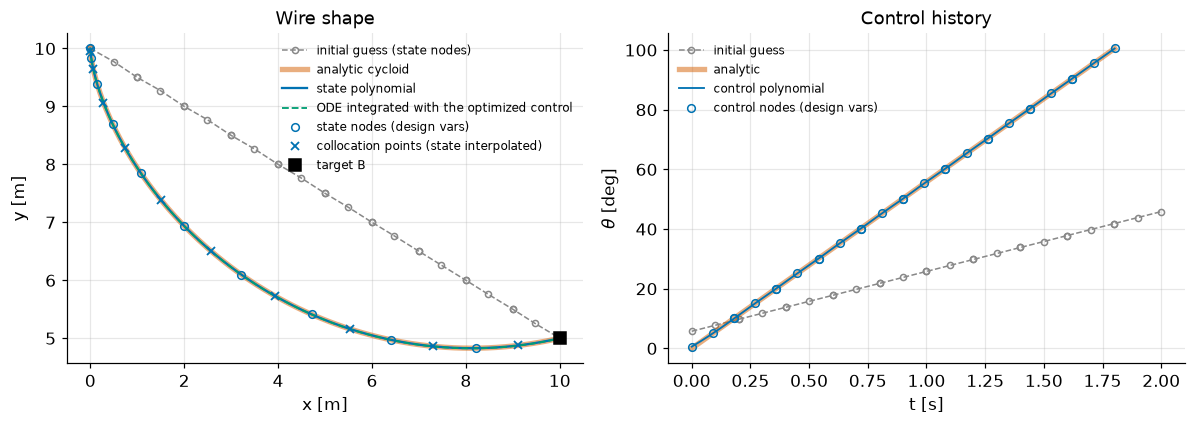

In [8]:
ts_n = p_colloc.get_val('phase0.timeseries.time')[:, 0]
x_n = p_colloc.get_val('phase0.timeseries.x')[:, 0]
y_n = p_colloc.get_val('phase0.timeseries.y')[:, 0]
th_n = p_colloc.get_val('phase0.timeseries.theta')[:, 0]

T_poly, poly = dense_states(p_colloc, p_colloc.model.phase0,
                            ['x', 'y', 'v'], ['xdot', 'ydot', 'vdot'])
with quiet():
    sim = p_colloc.model.phase0.simulate(times_per_seg=20)
d = {k: sim.get_val(f'phase0.timeseries.{k}')[:, 0]
     for k in ('time', 'x', 'y', 'theta')}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(guess['x'], guess['y'], 'o--', ms=4, mfc='none', lw=1, color=COLORS['gray'],
         label='initial guess (state nodes)')
ax1.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.5,
         label='analytic cycloid')
ax1.plot(poly['x'], poly['y'], color=COLORS['dymos'], lw=1.5, label='state polynomial')
ax1.plot(d['x'], d['y'], '--', color=COLORS['secondary'], lw=1.2,
         label='ODE integrated with the optimized control')
gd = p_colloc.model.phase0.options['transcription'].grid_data
i_state = gd.subset_node_indices['state_input']  # segment boundaries: state design variables
i_col = gd.subset_node_indices['col']            # segment midpoints: defects enforced here
ax1.plot(x_n[i_state], y_n[i_state], 'o', ms=5, mfc='none', color=COLORS['dymos'],
         label='state nodes (design vars)')
ax1.plot(x_n[i_col], y_n[i_col], 'x', ms=5, mew=1.2, color=COLORS['dymos'],
         label='collocation points (state interpolated)')
ax1.plot(XF, YF, 's', ms=8, color='k', label='target B')
ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]'); ax1.set_title('Wire shape')
ax1.legend(fontsize=8)

ax2.plot(guess['time'], np.degrees(guess['theta']), 'o--', ms=4, mfc='none', lw=1,
         color=COLORS['gray'], label='initial guess')
ax2.plot(ana['t'], np.degrees(ana['theta']), color=COLORS['analytic'], lw=3.5,
         alpha=0.5, label='analytic')
ax2.plot(d['time'], np.degrees(d['theta']), color=COLORS['dymos'], lw=1.2,
         label='control polynomial')
ax2.plot(ts_n, np.degrees(th_n), 'o', ms=5, mfc='none', color=COLORS['dymos'],
         label='control nodes (design vars)')
ax2.set_xlabel('t [s]'); ax2.set_ylabel(r'$\theta$ [deg]')
ax2.set_title('Control history')
ax2.legend(fontsize=8)
fig.tight_layout()

### Watching the defects close

Under shooting (notebook 01) every optimizer iterate was a dynamically
feasible trajectory that ended in the wrong place. Under collocation it is
the other way around: the endpoints are right from the first iterate (they
are fixed design variables), and the *dynamics* are wrong until the defects
converge. The recorder attached to the solve above kept every driver
evaluation. Each recorded case holds the design-variable vector $z$: the
duration, the state nodes and the control nodes. Everything else in the
animation is reconstructed from $z$ with the cubic Hermite interpolant of section 1:
the state polynomial on every segment (the blue curve, with the state design
variables as circles and the collocation points as crosses), the segment-midpoint states, the polynomial's slope there, and the
ODE's right-hand side there. The defect is the difference between the last two.

In the left panel each collocation point carries two arrows: the **slope of
the state polynomial** (black) and the **velocity the dynamics prescribe**
for that state and control (magenta). At the guess they disagree at every
collocation point, in direction and in length. The solve is finished when
every pair of arrows coincides. The arrows appear at the collocation points
only: at the state nodes the polynomial's slope equals the ODE rate by
construction, because the Hermite interpolant is built from those rates.

In [9]:
def hermite_midpoints(z, num_segments):
    '''Reconstruct, from a design-variable vector z of the Gauss-Lobatto
    brachistochrone: the state nodes, the state and control polynomials on
    every segment, the Hermite midpoint states, the polynomial slope and the
    ODE rate at the midpoints, and the defects.'''
    N = num_segments
    tf = z['phase0.t_duration'][0]
    h = tf / N
    x = np.concatenate([[0.0], z['phase0.states:x'].ravel(), [XF]])  # fixed ends restored
    y = np.concatenate([[10.0], z['phase0.states:y'].ravel(), [YF]])
    v = np.concatenate([[0.0], z['phase0.states:v'].ravel()])
    theta = z['phase0.controls:theta'].ravel()
    th_end, th_mid = theta[0::2], theta[1::2]        # control nodes: ends and midpoints
    S = np.vstack([x, y, v])                          # states at the segment ends
    F = np.vstack(brach_rates(x, y, v, th_end))       # rates at the segment ends
    S_c = 0.5 * (S[:, :-1] + S[:, 1:]) + h / 8 * (F[:, :-1] - F[:, 1:])
    Sdot_c = 1.5 / h * (S[:, 1:] - S[:, :-1]) - 0.25 * (F[:, :-1] + F[:, 1:])
    F_c = np.vstack(brach_rates(S_c[0], S_c[1], S_c[2], th_mid))
    # Dense evaluation of the polynomials: cubic Hermite for the states,
    # quadratic through the three control nodes for theta
    s = np.linspace(0, 1, 25)
    H = [2*s**3 - 3*s**2 + 1, s**3 - 2*s**2 + s, -2*s**3 + 3*s**2, s**3 - s**2]
    poly = {name: np.concatenate([H[0] * S[j, k] + H[1] * h * F[j, k]
                                  + H[2] * S[j, k + 1] + H[3] * h * F[j, k + 1]
                                  for k in range(N)])
            for j, name in enumerate(('x', 'y', 'v'))}
    poly['theta'] = np.concatenate([th_end[k] * (1 - s) * (1 - 2 * s) + th_mid[k] * 4 * s * (1 - s)
                                    + th_end[k + 1] * s * (2 * s - 1) for k in range(N)])
    poly['t'] = np.concatenate([(k + s) * h for k in range(N)])
    return {'tf': tf, 't_nodes': np.linspace(0, tf, N + 1), 'x': x, 'y': y, 'v': v,
            't_ctrl': np.linspace(0, tf, 2 * N + 1), 'theta': theta, 'poly': poly,
            'x_c': S_c[0], 'y_c': S_c[1], 'v_c': S_c[2], 't_c': (np.arange(N) + 0.5) * h,
            'slope_c': Sdot_c[:2], 'ode_c': F_c[:2],
            'defect': np.abs(Sdot_c - F_c).max()}


NUM_SEG = 10
frames = [hermite_midpoints(case.get_design_vars(scaled=False), NUM_SEG)
          for case in om.CaseReader(rec_file).get_cases('driver')]
rec_file.unlink()  # frames are in memory; nothing left on disk
print(f'{len(frames)} recorded driver evaluations, success={res.success}, '
      f'tf = {frames[-1]["tf"]:.6f} s, final max |defect| = {frames[-1]["defect"]:.1e}')

57 recorded driver evaluations, success=True, tf = 1.801605 s, final max |defect| = 2.5e-09


In [10]:
show = list(range(0, len(frames), 3))  # every third evaluation, plus the last
if show[-1] != len(frames) - 1:
    show.append(len(frames) - 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2), dpi=90,
                                    gridspec_kw={'width_ratios': [1.3, 1, 1]})

ax1.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.5,
         label='analytic cycloid')
ax1.plot(XF, YF, 's', ms=8, color='k', label='target B')
poly_xy, = ax1.plot([], [], lw=1.5, color=COLORS['dymos'], label='state polynomial')
nodes_xy, = ax1.plot([], [], 'o', ms=5, mfc='none', color=COLORS['dymos'],
                     label='state nodes (design vars)')
col_xy, = ax1.plot([], [], 'x', ms=5, mew=1.2, color=COLORS['dymos'],
                   label='collocation points (state interpolated)')
f0 = frames[0]
q_slope = ax1.quiver(f0['x_c'], f0['y_c'], *f0['slope_c'], angles='xy',
                     scale_units='xy', scale=10, width=0.004, color='k', zorder=5)
q_ode = ax1.quiver(f0['x_c'], f0['y_c'], *f0['ode_c'], angles='xy',
                   scale_units='xy', scale=10, width=0.004, color=COLORS['accent'],
                   zorder=6)
info = ax1.text(0.03, 0.03, '', transform=ax1.transAxes, fontsize=9)
all_x = np.concatenate([f['x'] for f in frames])
all_y = np.concatenate([f['y'] for f in frames])
ax1.set_xlim(min(all_x.min(), 0) - 0.5, max(all_x.max(), XF) + 1.0)
ax1.set_ylim(min(all_y.min(), YF) - 0.8, max(all_y.max(), 10) + 0.8)
ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]')
ax1.set_title('State polynomial and collocation-point velocities')
handles, labels = ax1.get_legend_handles_labels()
handles += [Line2D([], [], color='k', lw=1.5), Line2D([], [], color=COLORS['accent'], lw=1.5)]
labels += ['polynomial slope at collocation pts', 'dynamics f(x, u) at collocation pts']
ax1.legend(handles, labels, fontsize=7, loc='upper right')

poly_v, = ax2.plot([], [], lw=1.2, color=COLORS['dymos'])
nodes_v, = ax2.plot([], [], 'o', ms=4, mfc='none', color=COLORS['dymos'])
col_v, = ax2.plot([], [], 'x', ms=4, mew=1.2, color=COLORS['dymos'])
ax2.plot(ana['t'], np.sqrt(2 * G * (10 - ana['y'])),   # energy conservation
         color=COLORS['analytic'], lw=3.5, alpha=0.5)
ax2.set_xlim(0, max(f['tf'] for f in frames) + 0.1)
ax2.set_ylim(-0.5, max(f['v'].max() for f in frames) + 1)
ax2.set_xlabel('t [s]'); ax2.set_ylabel('v [m/s]'); ax2.set_title('Speed polynomial')

ax3.plot(ana['t'], np.degrees(ana['theta']), color=COLORS['analytic'], lw=3.5,
         alpha=0.5)
poly_th, = ax3.plot([], [], lw=1.2, color=COLORS['dymos'])
nodes_th, = ax3.plot([], [], 'o', ms=4, mfc='none', color=COLORS['dymos'])
ax3.set_xlim(0, max(f['tf'] for f in frames) + 0.1)
ax3.set_ylim(-5, max(np.degrees(f['theta']).max() for f in frames) + 10)
ax3.set_xlabel('t [s]'); ax3.set_ylabel(r'$\theta$ [deg]'); ax3.set_title('Control polynomial')


def update(j):
    k = show[j]
    f = frames[k]
    poly_xy.set_data(f['poly']['x'], f['poly']['y'])
    nodes_xy.set_data(f['x'], f['y'])
    col_xy.set_data(f['x_c'], f['y_c'])
    q_slope.set_offsets(np.c_[f['x_c'], f['y_c']]); q_slope.set_UVC(*f['slope_c'])
    q_ode.set_offsets(np.c_[f['x_c'], f['y_c']]); q_ode.set_UVC(*f['ode_c'])
    poly_v.set_data(f['poly']['t'], f['poly']['v'])
    nodes_v.set_data(f['t_nodes'], f['v'])
    col_v.set_data(f['t_c'], f['v_c'])
    poly_th.set_data(f['poly']['t'], np.degrees(f['poly']['theta']))
    nodes_th.set_data(f['t_ctrl'], np.degrees(f['theta']))
    info.set_text(f"evaluation {k}/{len(frames) - 1}:   $t_f$ = {f['tf']:.3f} s,"
                  f"   max |defect| = {f['defect']:.1e}")
    return poly_xy, nodes_xy, col_xy, q_slope, q_ode, poly_v, nodes_v, col_v, poly_th, nodes_th, info


ani = animation.FuncAnimation(fig, update, frames=len(show), interval=200, blit=True)
plt.close(fig)  # display only the animation player below, not a static copy
HTML(ani.to_jshtml(default_mode='once'))

The endpoints never move; everything in between does. In the early frames
the polynomial takes shapes that are not trajectories of anything (it is just
50 numbers the optimizer is adjusting), and the two arrows at each
collocation point disagree in both length and direction. The polynomial only
becomes the cycloid as the arrows align. The convergence history below shows
the defects falling by four orders of magnitude while $t_f$ still wanders:
SLSQP restores feasibility first and settles the objective last, with both
converging together only in the final evaluations.

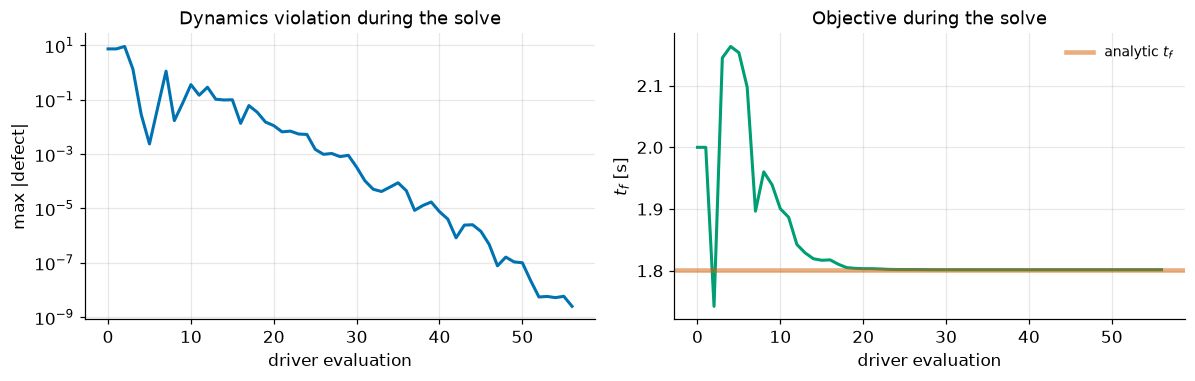

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.semilogy([f['defect'] for f in frames], color=COLORS['dymos'])
ax1.set_xlabel('driver evaluation'); ax1.set_ylabel('max |defect|')
ax1.set_title('Dynamics violation during the solve')
ax2.plot([f['tf'] for f in frames], color=COLORS['secondary'])
ax2.axhline(ana['tf'], color=COLORS['analytic'], lw=3, alpha=0.5, label='analytic $t_f$')
ax2.set_xlabel('driver evaluation'); ax2.set_ylabel('$t_f$ [s]')
ax2.set_title('Objective during the solve'); ax2.legend(fontsize=9)
fig.tight_layout()

### What a zero defect does and does not guarantee

At convergence the arrows coincide: the polynomial's slope equals the
dynamics *at the collocation points*. That is all the defect constraints
say. Between the collocation points the polynomial is free to drift from the
true solution, and at the collocation points themselves its *value* need not
be right either. Only its slope is.

On a coarse grid this is visible on the brachistochrone itself. Below,
the problem is solved with 1 and with 2 segments. The dashed curve is the
ODE integrated with the *same* control from the same initial state, the
trajectory the polynomial claims to be. The right-hand panels plot the
difference, with the collocation times marked: the error is not zero at the
collocation points, because the defects only pin the slope there. With one
segment the cubic misses the integrated path by over half a meter; with two,
by a few centimeters; section 2's grid of 10 segments brings it below a
millimeter. (Note, in the left panels, that the arrows still coincide
exactly on both grids.)

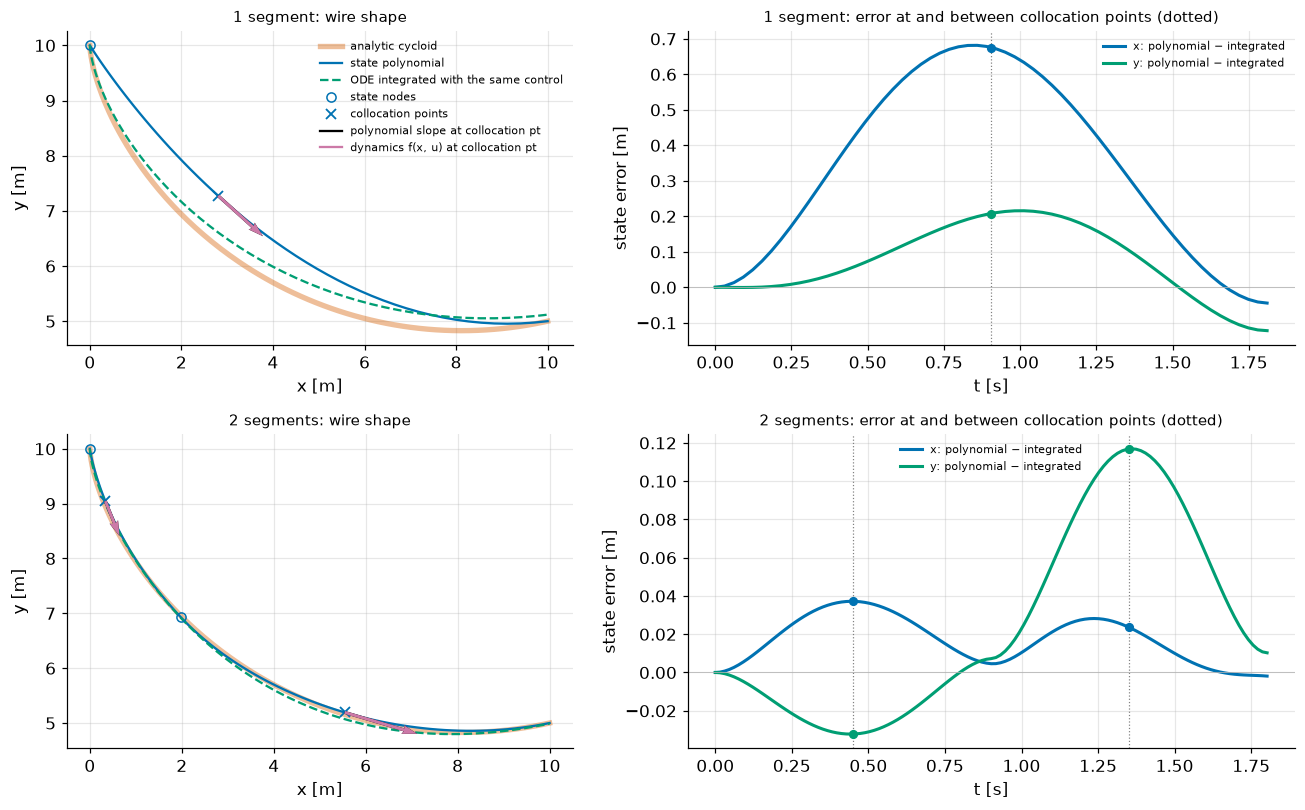

In [12]:
def collocation_arrows(p):
    '''Per segment: the collocation time and midpoint position, the slope of
    the Hermite state polynomial there, and the velocity the ODE prescribes
    there (midpoint of the cubic Hermite interpolant).'''
    t = p.get_val('phase0.timeseries.time')[:, 0]
    x = p.get_val('phase0.timeseries.x')[:, 0]
    y = p.get_val('phase0.timeseries.y')[:, 0]
    v = p.get_val('phase0.timeseries.v')[:, 0]
    th = p.get_val('phase0.timeseries.theta')[:, 0]
    arrows = []
    for k in range(len(t) // 3):   # order 3: timeseries nodes are [end, mid, end] per segment
        i0, i1, i2 = 3 * k, 3 * k + 1, 3 * k + 2
        h = t[i2] - t[i0]
        F0 = np.array(brach_rates(x[i0], y[i0], v[i0], th[i0])[:2])
        F2 = np.array(brach_rates(x[i2], y[i2], v[i2], th[i2])[:2])
        slope = 1.5 / h * (np.array([x[i2], y[i2]]) - np.array([x[i0], y[i0]])) - 0.25 * (F0 + F2)
        arrows.append((t[i1], x[i1], y[i1], slope, brach_rates(x[i1], y[i1], v[i1], th[i1])[:2]))
    return arrows


fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), gridspec_kw={'width_ratios': [1, 1.2]})
for row, ns in zip(axes, [1, 2]):
    p = build_brachistochrone_collocation(num_segments=ns)
    with quiet():
        p.run_driver()
        sim = p.model.phase0.simulate(times_per_seg=60)
    T, poly = dense_states(p, p.model.phase0, ['x', 'y'], ['xdot', 'ydot'], pts_per_seg=60)
    col = collocation_arrows(p)
    st = sim.get_val('phase0.timeseries.time')[:, 0]
    sx = np.interp(T, st, sim.get_val('phase0.timeseries.x')[:, 0])
    sy = np.interp(T, st, sim.get_val('phase0.timeseries.y')[:, 0])
    xn = p.get_val('phase0.timeseries.x')[0::3]; yn = p.get_val('phase0.timeseries.y')[0::3]

    ax = row[0]
    ax.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.4,
            label='analytic cycloid')
    ax.plot(poly['x'], poly['y'], color=COLORS['dymos'], lw=1.5, label='state polynomial')
    ax.plot(sx, sy, '--', color=COLORS['secondary'], lw=1.5,
            label='ODE integrated with the same control')
    ax.plot(xn, yn, 'o', ms=6, mfc='none', color=COLORS['dymos'], label='state nodes')
    ax.plot([c[1] for c in col], [c[2] for c in col], 'x', ms=6, mew=1.2,
            color=COLORS['dymos'], label='collocation points')
    for (tc, xc, yc, slope, ode) in col:
        ax.quiver(xc, yc, *slope, angles='xy', scale_units='xy', scale=6,
                  width=0.006, color='k', zorder=5)
        ax.quiver(xc, yc, *ode, angles='xy', scale_units='xy', scale=6,
                  width=0.006, color=COLORS['accent'], zorder=6)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.set_title(f'{ns} segment{"s" if ns > 1 else ""}: wire shape', fontsize=10)
    if ns == 1:
        handles, labels = ax.get_legend_handles_labels()
        handles += [Line2D([], [], color='k', lw=1.5),
                    Line2D([], [], color=COLORS['accent'], lw=1.5)]
        labels += ['polynomial slope at collocation pt', 'dynamics f(x, u) at collocation pt']
        ax.legend(handles, labels, fontsize=7, loc='upper right')

    ax = row[1]
    ax.plot(T, poly['x'] - sx, color=COLORS['dymos'], label='x: polynomial − integrated')
    ax.plot(T, poly['y'] - sy, color=COLORS['secondary'], label='y: polynomial − integrated')
    for (tc, *_rest) in col:
        ax.axvline(tc, color='0.5', ls=':', lw=0.8)
        ax.plot(tc, np.interp(tc, T, poly['x'] - sx), 'o', ms=5, color=COLORS['dymos'])
        ax.plot(tc, np.interp(tc, T, poly['y'] - sy), 'o', ms=5, color=COLORS['secondary'])
    ax.axhline(0, color='0.7', lw=0.5)
    ax.set_xlabel('t [s]'); ax.set_ylabel('state error [m]')
    ax.set_title(f'{ns} segment{"s" if ns > 1 else ""}: error at and between '
                 f'collocation points (dotted)', fontsize=10)
    ax.legend(fontsize=7)
fig.tight_layout()

### Interactive: order, node family and segment count

Pick a transcription and solve from scratch. Every solve takes well under a
second, so the trade-off between segment count and polynomial order can be
explored live: compare, for instance, 2 segments of order 9 with 8 segments
of order 3 (both have roughly the same number of variables). The circles
mark the state and control design variables; the thin line is the
`simulate()` check. (Gauss–Lobatto orders must be odd.)

In [13]:
def render_solution_png(p, title):
    tn = p.get_val('phase0.timeseries.time')[:, 0]
    xn = p.get_val('phase0.timeseries.x')[:, 0]
    yn = p.get_val('phase0.timeseries.y')[:, 0]
    thn = p.get_val('phase0.timeseries.theta')[:, 0]
    _, poly = dense_states(p, p.model.phase0, ['x', 'y'], ['xdot', 'ydot'])
    with quiet():
        sim = p.model.phase0.simulate(times_per_seg=20)
    dd = {k: sim.get_val(f'phase0.timeseries.{k}')[:, 0] for k in ('time', 'x', 'y', 'theta')}
    with plt.ioff():
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
        ax1.plot(ana['x'], ana['y'], color=COLORS['analytic'], lw=3.5, alpha=0.5,
                 label='analytic cycloid')
        ax1.plot(poly['x'], poly['y'], color=COLORS['dymos'], lw=1.5, label='state polynomial')
        ax1.plot(dd['x'], dd['y'], '--', color=COLORS['secondary'], lw=1.2,
                 label='ODE integrated with the optimized control')
        gd = p.model.phase0.options['transcription'].grid_data
        i_state, i_col = gd.subset_node_indices['state_input'], gd.subset_node_indices['col']
        ax1.plot(xn[i_state], yn[i_state], 'o', ms=5, mfc='none', color=COLORS['dymos'],
                 label='state nodes (design vars)')
        ax1.plot(xn[i_col], yn[i_col], 'x', ms=5, mew=1.2, color=COLORS['dymos'],
                 label='collocation points')
        ax1.set_xlabel('x [m]'); ax1.set_ylabel('y [m]'); ax1.legend(fontsize=8)
        ax1.set_title(title, loc='left', fontsize=10)
        ax2.plot(ana['t'], np.degrees(ana['theta']), color=COLORS['analytic'], lw=3.5,
                 alpha=0.5)
        ax2.plot(dd['time'], np.degrees(dd['theta']), color=COLORS['dymos'], lw=1.2)
        ax2.plot(tn, np.degrees(thn), 'o', ms=5, mfc='none', color=COLORS['dymos'],
                 label='control nodes (design vars)')
        ax2.set_xlabel('t [s]'); ax2.set_ylabel(r'$\theta$ [deg]'); ax2.legend(fontsize=8)
        fig.tight_layout()
        import io
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
    return buf.getvalue()


family_w = widgets.Dropdown(options=['GaussLobatto', 'Radau'], value='GaussLobatto',
                            description='family')
order_w = widgets.SelectionSlider(options=[3, 5, 7, 9], value=3, description='order')
ns_w = widgets.IntSlider(value=4, min=1, max=20, description='segments')
btn = widgets.Button(description='Solve', button_style='primary')


def solve_and_summarize(family, num_segments, order):
    p = build_brachistochrone_collocation(num_segments, order, family)
    t0 = time.perf_counter()
    with quiet():
        r = p.run_driver()
    wall = time.perf_counter() - t0
    tf = p.get_val('phase0.timeseries.time')[-1, 0]
    nvars = sum(np.asarray(v).size for v in p.driver.get_design_var_values().values())
    png = render_solution_png(p, f'{family}, {num_segments} seg x order {order}:')
    return png, (f'{nvars} design variables, |tf error| = {abs(tf - ana["tf"]):.2e} s, '
                 f'wall {wall:.2f} s, success={r.success}')


# One persistent image and one status line; the button only updates their values
png0, text0 = solve_and_summarize(family_w.value, ns_w.value, order_w.value)
img_w = widgets.Image(value=png0, format='png', width=980)
status_w = widgets.Label(value=text0)


def on_solve(_):
    status_w.value = (f'solving: {family_w.value}, {ns_w.value} segments of order '
                      f'{order_w.value} ...')
    img_w.value, status_w.value = solve_and_summarize(family_w.value, ns_w.value, order_w.value)


btn.on_click(on_solve)
display(widgets.VBox([widgets.HBox([family_w, order_w, ns_w, btn]), status_w, img_w]))

---
## 3. The total Jacobian

In single shooting (notebook 01) the rows of the boundary constraints
touched every design variable, because every control node influences the
integrated final state, while the control-continuity rows were sparse.
Multiple shooting (notebook 02) broke the coupled rows into a staircase.
Collocation is **sparse**: a defect involves the state and control nodes of
its own segment and nothing else, with one exception. Every defect also
depends on the duration, because the segment length $h = t_f / K$ multiplies
the ODE's right-hand side, so $t_f$ is the single dense column.

The matrix on the left belongs to a 4-segment version of the section 2
problem (20 variables, 15 constraints), small enough to label every row and
column. Read the row of $\Delta x_k$, the $x$ defect of segment $k$: it
touches $x$ at the two ends of the segment, nodes $k$ and $k+1$, through the
slope of the Hermite polynomial; $v$ at the same nodes and the control at
nodes $2k$, $2k+1$ and $2k+2$, through the rates that enter the interpolant
and the dynamics at the midpoint; and $t_f$. The $y$ and $v$ defects follow
the same pattern, except that no defect other than $x$'s own touches $x$,
because $x$ does not appear in the dynamics. On the
right is the 10-segment matrix that notebook 01 previewed at the end of
Lecture 9: the same pattern with longer stripes. This structure is what
sparse NLP solvers (SNOPT, IPOPT) are built to exploit, and why collocation
is the default transcription for large trajectory problems.

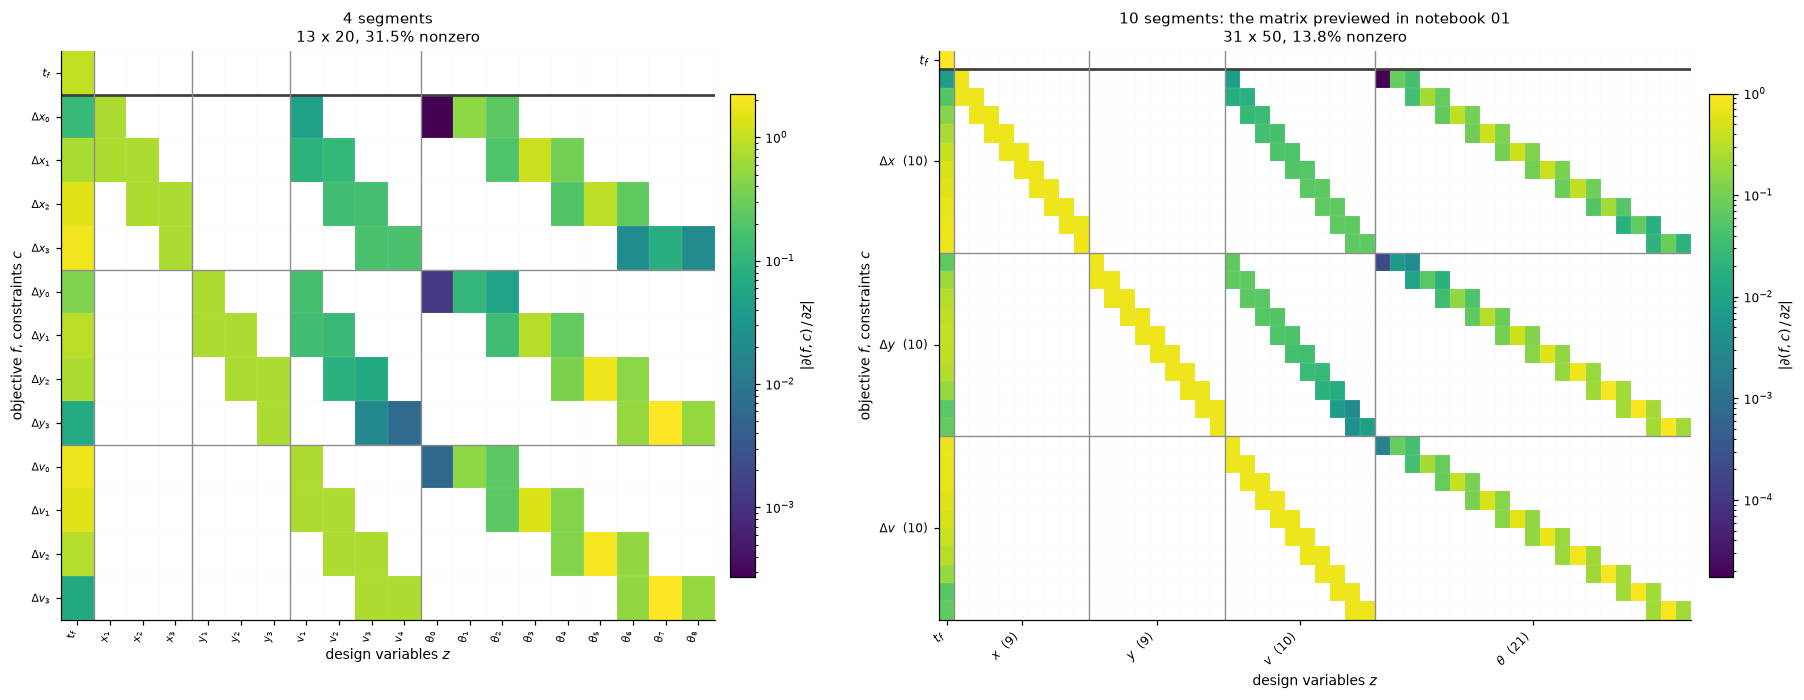

In [14]:
def entry_labels(num_segments):
    '''One label per row and per column of the brachistochrone NLP, in the
    order OpenMDAO uses: t_f, then the free state nodes of x, y, v, then the
    control nodes; objective, then the defects per segment.'''
    N = num_segments
    cols = (['$t_f$'] + [f'$x_{{{k}}}$' for k in range(1, N)]            # x, y: ends fixed
            + [f'$y_{{{k}}}$' for k in range(1, N)]
            + [f'$v_{{{k}}}$' for k in range(1, N + 1)]                  # v: start fixed
            + [fr'$\theta_{{{k}}}$' for k in range(2 * N + 1)])
    rows = (['$t_f$'] + [fr'$\Delta x_{{{k}}}$' for k in range(N)]
            + [fr'$\Delta y_{{{k}}}$' for k in range(N)]
            + [fr'$\Delta v_{{{k}}}$' for k in range(N)])
    return rows, cols


# A 4-segment version of the section 2 problem, small enough to label every entry
N_JAC = 4
p_jac = build_brachistochrone_collocation(num_segments=N_JAC)
with quiet():
    p_jac.run_driver()
J4, of4, wrt4 = total_jacobian(p_jac)
rows, cols = entry_labels(N_JAC)
assert (len(rows), len(cols)) == J4.shape

J10, of10, wrt10 = total_jacobian(p_colloc)   # the 10-segment matrix previewed in notebook 01
of10, wrt10 = symbol_labels(of10), symbol_labels(wrt10)   # same symbols as on the left

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6.5),
                               gridspec_kw={'width_ratios': [1, 1.15]})
plot_jacobian(J4, of4, wrt4, ax=ax1, title='4 segments', row_labels=rows, col_labels=cols)
plot_jacobian(J10, of10, wrt10, ax=ax2,
              title='10 segments: the matrix previewed in notebook 01')
fig.tight_layout()

### Convergence on a smooth problem

For smooth dynamics and controls, collocation converges *fast* with
refinement, and every solve is so cheap that a mesh sweep costs seconds in
total.

One caveat on the wall-time panel: SLSQP is a *dense* SQP method. It stores
and factors a dense quadratic subproblem of size $n$ at every iteration, so
its cost grows roughly as $n^3$ no matter how sparse the Jacobian is, and the
curve bends upward. Collocation reaches its full potential only with a sparse
solver; dymos drives SNOPT and IPOPT through `pyoptsparse`, which is not part
of this course environment.

  2 segments: |tf error| = 4.45e-04 s, wall 0.05 s
  4 segments: |tf error| = 3.01e-05 s, wall 0.08 s
  8 segments: |tf error| = 3.50e-06 s, wall 0.14 s
 16 segments: |tf error| = 1.04e-06 s, wall 0.28 s
 32 segments: |tf error| = 4.82e-07 s, wall 0.98 s


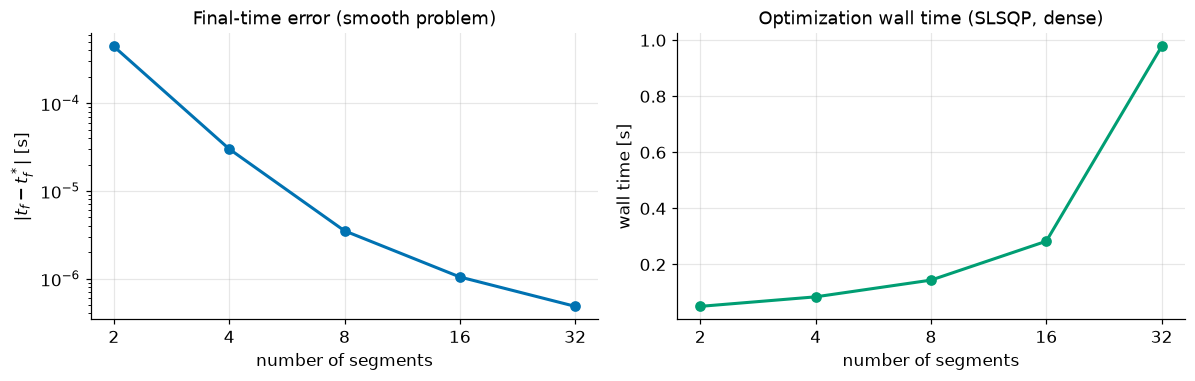

In [15]:
sweep = {}
for ns in [2, 4, 8, 16, 32]:
    p = build_brachistochrone_collocation(num_segments=ns)
    t0 = time.perf_counter()
    with quiet():
        p.run_driver()
    sweep[ns] = {'err': abs(p.get_val('phase0.timeseries.time')[-1, 0] - ana['tf']),
                 'wall': time.perf_counter() - t0}
    print(f"{ns:3d} segments: |tf error| = {sweep[ns]['err']:.2e} s, "
          f"wall {sweep[ns]['wall']:.2f} s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ns_list = list(sweep)
ax1.loglog(ns_list, [sweep[n]['err'] for n in ns_list], 'o-', color=COLORS['dymos'])
ax1.set_xlabel('number of segments'); ax1.set_ylabel(r'$|t_f - t_f^*|$ [s]')
ax1.set_title('Final-time error (smooth problem)')
ax2.semilogx(ns_list, [sweep[n]['wall'] for n in ns_list], 'o-',
             color=COLORS['secondary'])
ax2.set_xlabel('number of segments'); ax2.set_ylabel('wall time [s]')
ax2.set_title('Optimization wall time (SLSQP, dense)')
for ax in (ax1, ax2):   # plain segment counts on the log axis instead of 2 x 10^0 style labels
    ax.set_xticks(ns_list, [str(n) for n in ns_list])
    ax.xaxis.set_minor_locator(NullLocator())
fig.tight_layout()

---
## 4. Discontinuous controls and automatic grid refinement

The minimum-time double integrator from notebooks 01/02 (start at
$v_0 = 0.5$ m/s, so the switch sits at $t_s \approx 0.56$ s, never on a
uniform grid boundary). This section uses the **Radau** transcription: with
order 3 the control has three nodes per segment (the LGR nodes), so it is
piecewise quadratic, and as in Lecture 9 it is allowed to jump at segment
boundaries (`continuity=False`). Collocation smears the switch exactly as
shooting did: the limitation was never the transcription, it is the
polynomial basis on a fixed grid.

What collocation adds is a cheap **per-segment error estimate**: the
converged polynomial is interpolated onto a finer set of points, its slope is
compared with the ODE evaluated there, and the mismatch, a residual the
collocation points themselves cannot see, is integrated over the segment.
With it comes **automatic grid refinement**: dymos's *ph* scheme raises the
polynomial order of any segment whose estimate exceeds the tolerance, or
splits it once the order limit is reached, and re-solves. A jump is the one
feature a higher-order polynomial handles badly (it rings around the
discontinuity, the Gibbs phenomenon), so here the order is capped at 3 and
every refinement step is a split: the segment containing the switch is
halved, the problem re-solved, and the segment halved again, until the
estimate meets the tolerance. The table below summarizes dymos's refinement
log: every other segment is at machine precision from the first pass on, and
only the one containing the switch is ever touched.

In [16]:
V0, D = 0.5, 1.0
TS = np.sqrt(D + V0**2 / 2) - V0
TF = 2 * np.sqrt(D + V0**2 / 2) - V0


class DoubleIntegratorODE(om.ExplicitComponent):

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('v', val=np.zeros(nn), units='m/s')
        self.add_input('u', val=np.zeros(nn), units='m/s**2')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('vdot', val=np.zeros(nn), units='m/s**2')
        ar = np.arange(nn)
        self.declare_partials('xdot', 'v', rows=ar, cols=ar, val=1.0)
        self.declare_partials('vdot', 'u', rows=ar, cols=ar, val=1.0)

    def compute(self, inputs, outputs):
        outputs['xdot'] = inputs['v']
        outputs['vdot'] = inputs['u']


def build_di_collocation(num_segments=8, order=3):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=400, tol=1e-9)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)
    phase = dm.Phase(ode_class=DoubleIntegratorODE,
                     transcription=dm.Radau(num_segments=num_segments, order=order))
    p.model.add_subsystem('phase0', phase)
    phase.set_time_options(fix_initial=True, duration_bounds=(0.3, 10), units='s')
    phase.add_state('x', fix_initial=True, fix_final=True, rate_source='xdot', units='m')
    phase.add_state('v', fix_initial=True, fix_final=True, rate_source='vdot', units='m/s')
    phase.add_control('u', units='m/s**2', lower=-1.0, upper=1.0,
                      continuity=False, rate_continuity=False)
    phase.add_objective('time', loc='final')
    p.setup()
    phase.set_time_val(initial=0.0, duration=2.0)
    phase.set_state_val('x', [0, D])
    phase.set_state_val('v', [V0, 0])
    phase.set_control_val('u', [1.0, -1.0])
    return p, phase


def dense_control(p, phase, name, pts_per_seg=60):
    '''The control polynomial dymos actually used: on each segment, the
    Lagrange interpolant through that segment's control nodes. Returns the
    dense curve and the control nodes (the design variables).'''
    gd = phase.options['transcription'].grid_data
    t_all = p.get_val('phase0.timeseries.time')[:, 0]
    u_all = p.get_val(f'phase0.timeseries.{name}')[:, 0]
    ctrl = set(gd.subset_node_indices['control_input'])
    T, U, t_nodes, u_nodes = [], [], [], []
    for k in range(gd.num_segments):
        i0, i1 = gd.segment_indices[k]
        idx = [i for i in range(i0, i1) if i in ctrl]
        tk, uk = t_all[idx], u_all[idx]
        poly = lagrange(tk - tk[0], uk)
        tt = np.linspace(0, t_all[i1 - 1] - tk[0], pts_per_seg)
        T.append(tt + tk[0]); U.append(poly(tt))
        t_nodes.append(tk); u_nodes.append(uk)
    return (np.concatenate(T), np.concatenate(U),
            np.concatenate(t_nodes), np.concatenate(u_nodes))


p_uni, phase_uni = build_di_collocation()
with quiet():
    p_uni.run_driver()
tf_uni = p_uni.get_val('phase0.timeseries.time')[-1, 0]
uni = dense_control(p_uni, phase_uni, 'u')
print(f'uniform grid (8 segments, order 3): tf = {tf_uni:.8f} '
      f'(error {abs(tf_uni - TF):.1e} s)')

uniform grid (8 segments, order 3): tf = 1.62201630 (error 7.0e-04 s)


In [17]:
import io
import re
from contextlib import redirect_stdout

p_ref, phase_ref = build_di_collocation()
# Pure h-refinement: with the order capped at 3, every refinement step splits segments
phase_ref.set_refine_options(refine=True, tol=1e-6, min_order=3, max_order=3)
log = io.StringIO()
with redirect_stdout(log):   # dymos prints the full grid at every iteration; summarized below
    dm.run_problem(p_ref, run_driver=True, simulate=False,
                   refine_method='ph', refine_iteration_limit=10)
if os.path.exists('grid_refinement.out'):
    os.remove('grid_refinement.out')  # refinement writes this log in the cwd

# The grid solved at each iteration and its per-segment error estimate, from the log
history = [{'ends': np.array(ends.split(','), float), 'err': np.array(err.split(','), float)}
           for ends, err in re.findall(
               r'Original Grid:\s*Number of Segments = \d+\s*Segment Ends = \[(.*?)\]'
               r'\s*Segment Order = \[.*?\]\s*Error = \[(.*?)\]', log.getvalue(), re.S)]
gd = phase_ref.options['transcription'].grid_data
if not history or len(history[-1]['err']) != gd.num_segments:   # limit hit: add the final grid
    history.append({'ends': gd.segment_ends, 'err': None})
tf_ref = p_ref.get_val('phase0.timeseries.time')[-1, 0]
ref = dense_control(p_ref, phase_ref, 'u')

print(f"{'iteration':>9s} {'segments':>9s} {'max error estimate':>19s}   segment containing t_s [s]")
for k, h in enumerate(history):
    ends_t = 0.5 * (h['ends'] + 1) * tf_ref
    j = np.searchsorted(ends_t, TS) - 1
    est = f"{h['err'].max():19.1e}" if h['err'] is not None else f"{'(final grid)':>19s}"
    print(f"{k:9d} {len(ends_t) - 1:9d} {est}   {ends_t[j]:.4f} .. {ends_t[j + 1]:.4f}"
          f"  (width {ends_t[j + 1] - ends_t[j]:.4f})")
print(f'\nuniform    : tf error {abs(tf_uni - TF):.1e} s  (8 segments)')
print(f'h-refined  : tf error {abs(tf_ref - TF):.1e} s  ({gd.num_segments} segments, all of order 3)')

iteration  segments  max error estimate   segment containing t_s [s]
        0         8             1.3e-03   0.4053 .. 0.6080  (width 0.2027)
        1        10             1.1e-04   0.5405 .. 0.6080  (width 0.0675)
        2        12             1.4e-05   0.5405 .. 0.5629  (width 0.0225)
        3        14             3.3e-06   0.5517 .. 0.5629  (width 0.0112)
        4        15             3.8e-06   0.5517 .. 0.5629  (width 0.0112)
        5        16             2.8e-07   0.5573 .. 0.5629  (width 0.0056)

uniform    : tf error 7.0e-04 s  (8 segments)
h-refined  : tf error 6.6e-06 s  (16 segments, all of order 3)


The first two panels show the control *polynomial* dymos used on every
segment (the Lagrange interpolant through that segment's control nodes),
with the nodes, the design variables, as markers; drawing straight lines
between the nodes would misrepresent a quadratic basis and hide what happens
between them. The third panel is the grid history: one row per refinement
iteration, with a tick at every segment boundary.

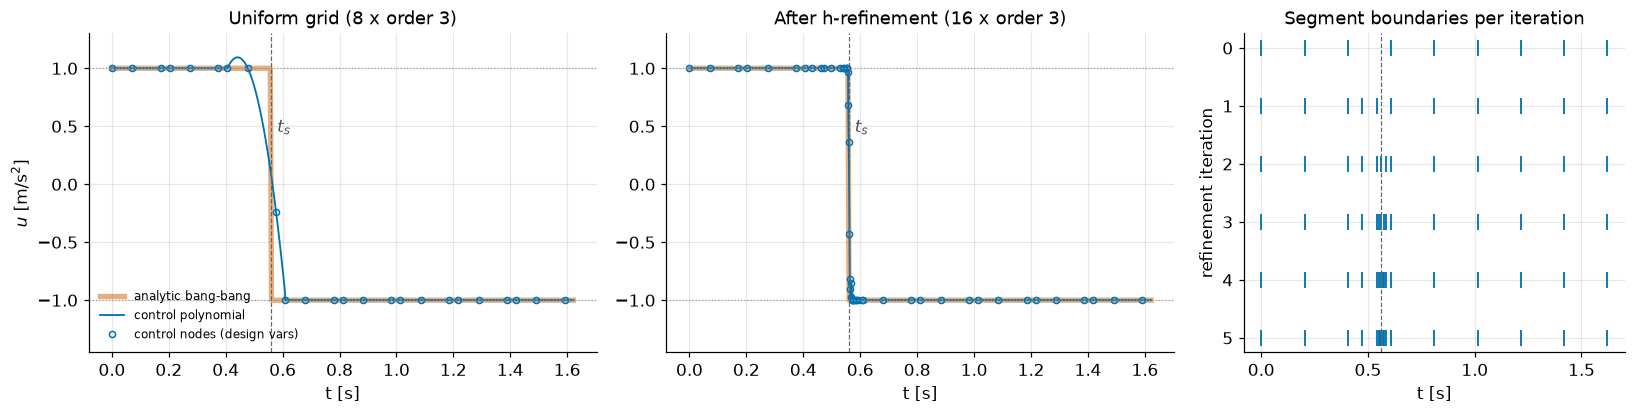

In [18]:
ana_t = np.linspace(0, TF, 400)
ana_u = np.where(ana_t < TS, 1.0, -1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9), gridspec_kw={'width_ratios': [1, 1, 0.75]})
for ax, (T, U, tn, un), title in [(axes[0], uni, 'Uniform grid (8 x order 3)'),
                                  (axes[1], ref, f'After h-refinement ({gd.num_segments} x order 3)')]:
    ax.plot(ana_t, ana_u, color=COLORS['analytic'], lw=3.5, alpha=0.5,
            label='analytic bang-bang')
    ax.plot(T, U, lw=1.2, color=COLORS['dymos'], label='control polynomial')
    ax.plot(tn, un, 'o', ms=4, mfc='none', color=COLORS['dymos'],
            label='control nodes (design vars)')
    ax.axhline(1, color='0.6', lw=0.8, ls=':'); ax.axhline(-1, color='0.6', lw=0.8, ls=':')
    ax.axvline(TS, color='0.4', lw=0.8, ls='--')
    ax.text(TS + 0.02, 0.45, '$t_s$', fontsize=11, color='0.3')
    ax.set_xlabel('t [s]'); ax.set_title(title); ax.set_ylim(-1.45, 1.3)
axes[0].set_ylabel(r'$u$ [m/s$^2$]')
axes[0].legend(fontsize=8, loc='lower left')

ax = axes[2]
for k, h in enumerate(history):
    ends_t = 0.5 * (h['ends'] + 1) * tf_ref
    ax.plot(ends_t, np.full_like(ends_t, k), '|', ms=10, mew=1.2, color=COLORS['dymos'])
ax.axvline(TS, color='0.4', lw=0.8, ls='--')
ax.set_yticks(range(len(history))); ax.invert_yaxis()
ax.set_xlabel('t [s]'); ax.set_ylabel('refinement iteration')
ax.set_title('Segment boundaries per iteration')
fig.tight_layout()

Three things to read off the figure:

- **Refinement localizes the error.** Iteration after iteration, only the
  segment containing the switch is split, and its width shrinks from a
  fifth of a second to a few milliseconds while the rest of the grid stays
  untouched. The final-time error drops by two orders of magnitude.
- **A finite misaligned mesh cannot represent the jump exactly.** The switch
  still falls *inside* a segment, and a quadratic cannot represent a jump, so
  the error shrinks with that segment's width. Continued $h$-refinement does
  converge, although no finite mesh is exact unless a boundary reaches the
  switch. Note too that the refinement stops when its *estimate* meets the
  tolerance, while
  the true final-time error is still above it: the estimate is a residual,
  not an error bound. Raising the order across the jump can still reduce
  integral and state errors, but it retains Gibbs oscillations and usually
  converges only algebraically; local splitting is typically more effective.
- **Bounds hold at the nodes only.** On the uniform grid the control
  overshoots the declared bounds between two nodes near the switch. The
  optimizer constrains the design variables, and the polynomial between them
  can do as it likes, the same lesson as section 2, now for a path bound
  instead of the dynamics.

The two formulations that actually nail this problem remain the ones from
Lecture 9's notebook 02 (two phases with the switch at the boundary: exact,
7 variables) and the indirect method of Lecture 11, where the switch emerges
from the optimality conditions themselves.

---
## 5. The SSTO launch, revisited

Notebook 02 closed with a single-stage-to-orbit launch solved by single
shooting: a planar vehicle over a flat Earth with exponential atmosphere,
thrust-pitch angle $\theta(t)$ as the control, minimum time to a 185 km
surrogate orbit-insertion endpoint. In this flat-Earth, constant-gravity model
the target matches orbital altitude and speed but is not a self-sustaining
circular orbit. The shooting solve took **76 s** of wall time and needed three
safeguards just to keep the integration alive on every optimizer iterate: a
duration bound below burnout, a smooth mass floor in the ODE, and a
propagation tolerance trimmed to the bare minimum.

Here is the same problem under Gauss–Lobatto collocation. The ODE is copied
unchanged, including the mass floor. It is inactive at the converged solution
but still protects the algebraic model if a trial iterate proposes a very small
or negative mass. What changes in the build:

- the orbit-insertion conditions become `fix_final=True` on $y$, $v_x$ and
  $v_y$, three fewer nonlinear constraints;
- the duration bound can be generous: no propagated trajectory has to survive
  a bad iterate, although the ODE must still remain defined at every trial node;
- the **scaling** carries over directly. Every state now appears as a design
  variable spanning five orders of magnitude, so each gets a `ref`, exactly
  as the boundary constraints did under shooting.

In [19]:
class LaunchVehicleODE(om.ExplicitComponent):
    '''Planar launch vehicle over a flat Earth, exponential atmosphere
    (identical to notebook 02).'''

    def initialize(self):
        self.options.declare('num_nodes', types=int)

    def setup(self):
        nn = self.options['num_nodes']
        self.add_input('y', val=np.zeros(nn), units='m')
        self.add_input('vx', val=np.zeros(nn), units='m/s')
        self.add_input('vy', val=np.zeros(nn), units='m/s')
        self.add_input('m', val=np.ones(nn), units='kg')
        self.add_input('theta', val=np.zeros(nn), units='rad')
        self.add_output('xdot', val=np.zeros(nn), units='m/s')
        self.add_output('ydot', val=np.zeros(nn), units='m/s')
        self.add_output('vxdot', val=np.zeros(nn), units='m/s**2')
        self.add_output('vydot', val=np.zeros(nn), units='m/s**2')
        self.add_output('mdot', val=np.zeros(nn), units='kg/s')
        # Complex-step partials: exact, no hand algebra
        self.declare_partials('*', '*', method='cs')

    def compute(self, i, o):
        g = 9.80665
        rho0, h_scale = 1.225, 8.44e3     # sea-level density, scale height
        CD, S = 0.5, 7.069                # drag coefficient, reference area
        F, Isp = 2.1e6, 265.2             # thrust, specific impulse

        rho = rho0 * np.exp(-i['y'] / h_scale)
        v = np.sqrt(i['vx']**2 + i['vy']**2 + 1e-12)  # eps: no 0/0 at launch
        drag_over_v = 0.5 * rho * v * CD * S

        # Smooth floor keeps m > 0 past burnout (needed under shooting only)
        m_min = 500.0
        m = m_min + 0.5 * (i['m'] - m_min + np.sqrt((i['m'] - m_min)**2 + 1.0))

        o['xdot'] = i['vx']
        o['ydot'] = i['vy']
        o['vxdot'] = (F * np.cos(i['theta']) - drag_over_v * i['vx']) / m
        o['vydot'] = (F * np.sin(i['theta']) - drag_over_v * i['vy']) / m - g
        o['mdot'] = -F / (g * Isp) * np.ones_like(i['m'])


def build_ssto_collocation(num_segments=20, order=3):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=500, tol=1e-7)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)

    phase = dm.Phase(ode_class=LaunchVehicleODE,
                     transcription=dm.GaussLobatto(num_segments=num_segments,
                                                   order=order))
    p.model.add_subsystem('phase0', phase)

    # No tight integration-survival bound is needed; keep a broad physical range
    phase.set_time_options(fix_initial=True, duration_bounds=(50, 400),
                           duration_ref=100.0, units='s')
    # States are design variables now, so each one is scaled with ref
    phase.add_state('x', fix_initial=True, rate_source='xdot', units='m', ref=1e5)
    phase.add_state('y', fix_initial=True, fix_final=True, rate_source='ydot',
                    units='m', ref=1.85e5)
    phase.add_state('vx', fix_initial=True, fix_final=True, rate_source='vxdot',
                    units='m/s', ref=7796.6961)
    phase.add_state('vy', fix_initial=True, fix_final=True, rate_source='vydot',
                    units='m/s', ref=1e3)
    phase.add_state('m', fix_initial=True, rate_source='mdot', units='kg', ref=1e5)
    # Value continuity is automatic (shared boundary node); slope matching is
    # left off, as for the shooting version of this problem in notebook 02
    phase.add_control('theta', units='rad', lower=-1.5, upper=1.5,
                      continuity=True, rate_continuity=False)
    phase.add_objective('time', loc='final', ref=100.0)

    p.setup(force_alloc_complex=True)  # required by the complex-step partials

    # Same linear-ramp guess as notebook 02; the orbit-insertion values at the
    # end of the y, vx, vy guesses are the imposed terminal conditions
    phase.set_time_val(initial=0.0, duration=125.0)
    phase.set_state_val('x', [0, 1.15e5])
    phase.set_state_val('y', [0, 1.85e5])
    phase.set_state_val('vx', [0, 7796.6961])
    phase.set_state_val('vy', [0, 0])
    phase.set_state_val('m', [117000, 1163])
    phase.set_control_val('theta', [1.5, -0.76])
    return p


p_ssto = build_ssto_collocation()
t0 = time.perf_counter()
res = p_ssto.run_driver()
wall_ssto = time.perf_counter() - t0

tf_ssto = p_ssto.get_val('phase0.timeseries.time')[-1, 0]
print(f'success={res.success}, wall {wall_ssto:.1f} s  '
      f'(single shooting in notebook 02: tf = 143.59 s in 76 s)')
print(f'tf = {tf_ssto:.2f} s')
print(f"final: y = {p_ssto.get_val('phase0.timeseries.y')[-1, 0] / 1e3:.1f} km, "
      f"vx = {p_ssto.get_val('phase0.timeseries.vx')[-1, 0]:.1f} m/s, "
      f"vy = {p_ssto.get_val('phase0.timeseries.vy')[-1, 0]:.2f} m/s, "
      f"m = {p_ssto.get_val('phase0.timeseries.m')[-1, 0]:.0f} kg")

success=True, wall 3.9 s  (single shooting in notebook 02: tf = 143.59 s in 76 s)
tf = 143.41 s
final: y = 185.0 km, vx = 7796.7 m/s, vy = 0.00 m/s, m = 1202 kg


An order of magnitude faster, without requiring the shooting problem's tight
integration-survival duration bound, and the NLP is a direct
scale-up of section 2: five state blocks, a control block, five defect blocks.
The Jacobian keeps the same banded structure at 139 variables as it had at
50.

=== SSTO launch, Gauss-Lobatto collocation (20 segments) ===

Design variables (z):
  t_duration                                 size    1
  x                                          size   20
  y                                          size   19
  vx                                         size   19
  vy                                         size   19
  m                                          size   20
  theta                                      size   41

Constraints (c(z)):
  defect: x                                  size   20
  defect: y                                  size   20
  defect: vx                                 size   20
  defect: vy                                 size   20
  defect: m                                  size   20

Objective (f(z)):
  t

--> NLP with 139 variables and 100 constraints


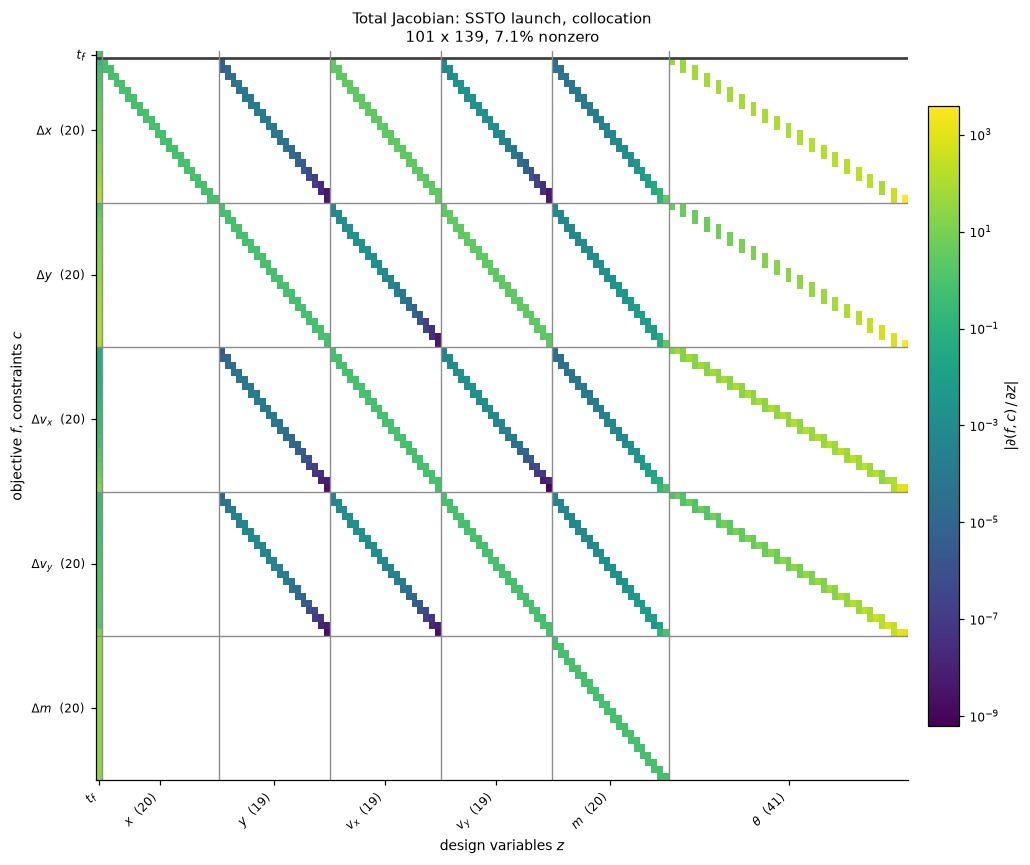

In [20]:
describe_nlp(p_ssto, title='SSTO launch, Gauss-Lobatto collocation (20 segments)');

J_ssto, of_s, wrt_s = total_jacobian(p_ssto)
fig, ax = plt.subplots(figsize=(10, 8))
plot_jacobian(J_ssto, symbol_labels(of_s), symbol_labels(wrt_s), ax=ax,
              title='Total Jacobian: SSTO launch, collocation')
fig.tight_layout()

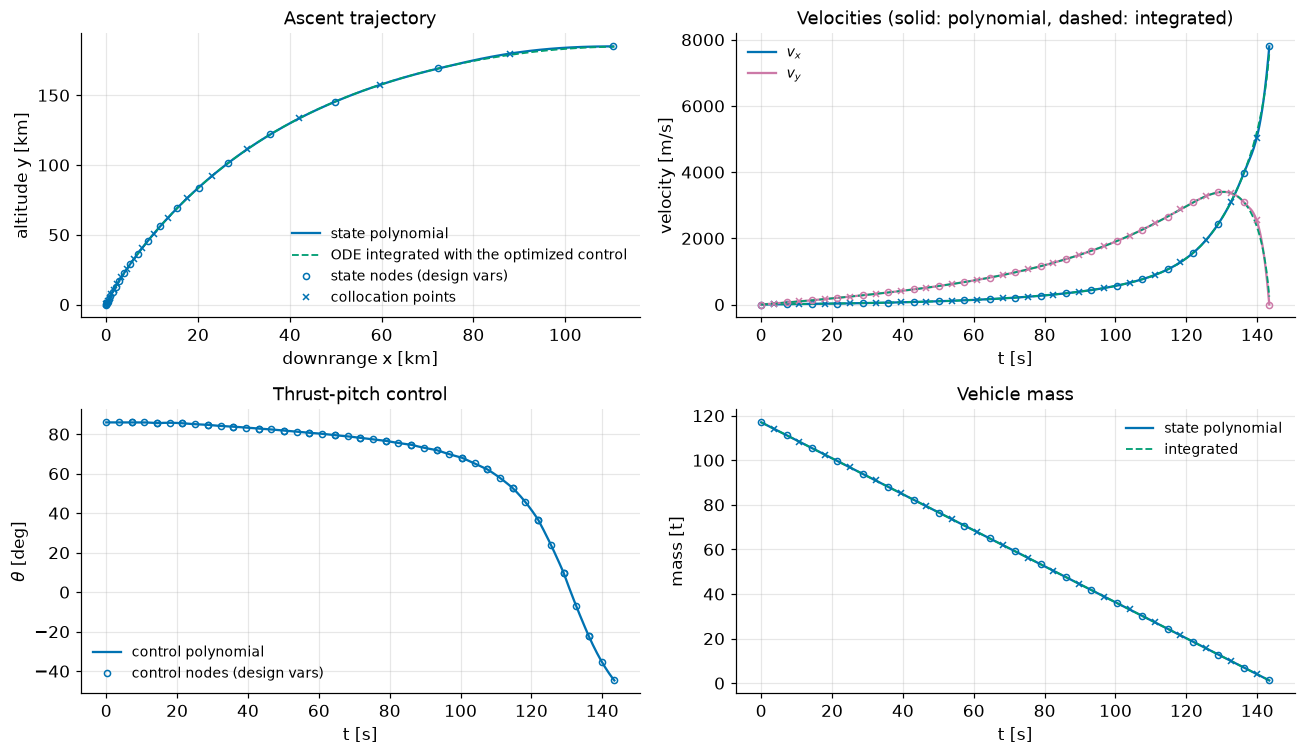

In [21]:
T_poly, poly = dense_states(p_ssto, p_ssto.model.phase0,
                            ['x', 'y', 'vx', 'vy', 'm'],
                            ['xdot', 'ydot', 'vxdot', 'vydot', 'mdot'])
with quiet():
    sim = p_ssto.model.phase0.simulate(times_per_seg=20)
d = {k: sim.get_val(f'phase0.timeseries.{k}')[:, 0]
     for k in ('time', 'x', 'y', 'vx', 'vy', 'theta', 'm')}
n = {k: p_ssto.get_val(f'phase0.timeseries.{k}')[:, 0]
     for k in ('time', 'x', 'y', 'vx', 'vy', 'theta', 'm')}
gd = p_ssto.model.phase0.options['transcription'].grid_data
i_state, i_col = gd.subset_node_indices['state_input'], gd.subset_node_indices['col']

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
ax = axes[0, 0]
ax.plot(poly['x'] / 1e3, poly['y'] / 1e3, color=COLORS['dymos'], lw=1.5,
        label='state polynomial')
ax.plot(d['x'] / 1e3, d['y'] / 1e3, '--', color=COLORS['secondary'], lw=1.2,
        label='ODE integrated with the optimized control')
ax.plot(n['x'][i_state] / 1e3, n['y'][i_state] / 1e3, 'o', ms=4, mfc='none',
        color=COLORS['dymos'], label='state nodes (design vars)')
ax.plot(n['x'][i_col] / 1e3, n['y'][i_col] / 1e3, 'x', ms=4, mew=1.0,
        color=COLORS['dymos'], label='collocation points')
ax.set_xlabel('downrange x [km]'); ax.set_ylabel('altitude y [km]')
ax.set_title('Ascent trajectory'); ax.legend(fontsize=9)

ax = axes[0, 1]
ax.plot(T_poly, poly['vx'], color=COLORS['dymos'], lw=1.5, label=r'$v_x$')
ax.plot(d['time'], d['vx'], '--', color=COLORS['secondary'], lw=1.2)
ax.plot(n['time'][i_state], n['vx'][i_state], 'o', ms=4, mfc='none', color=COLORS['dymos'])
ax.plot(n['time'][i_col], n['vx'][i_col], 'x', ms=4, mew=1.0, color=COLORS['dymos'])
ax.plot(T_poly, poly['vy'], color=COLORS['accent'], lw=1.5, label=r'$v_y$')
ax.plot(d['time'], d['vy'], '--', color=COLORS['secondary'], lw=1.2)
ax.plot(n['time'][i_state], n['vy'][i_state], 'o', ms=4, mfc='none', color=COLORS['accent'])
ax.plot(n['time'][i_col], n['vy'][i_col], 'x', ms=4, mew=1.0, color=COLORS['accent'])
ax.set_xlabel('t [s]'); ax.set_ylabel('velocity [m/s]')
ax.set_title('Velocities (solid: polynomial, dashed: integrated)'); ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(d['time'], np.degrees(d['theta']), color=COLORS['dymos'], lw=1.5,
        label='control polynomial')
ax.plot(n['time'], np.degrees(n['theta']), 'o', ms=4, mfc='none',
        color=COLORS['dymos'], label='control nodes (design vars)')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [deg]')
ax.set_title('Thrust-pitch control'); ax.legend(fontsize=9)

ax = axes[1, 1]
ax.plot(T_poly, poly['m'] / 1e3, color=COLORS['dymos'], lw=1.5, label='state polynomial')
ax.plot(d['time'], d['m'] / 1e3, '--', color=COLORS['secondary'], lw=1.2,
        label='integrated')
ax.plot(n['time'][i_state], n['m'][i_state] / 1e3, 'o', ms=4, mfc='none', color=COLORS['dymos'])
ax.plot(n['time'][i_col], n['m'][i_col] / 1e3, 'x', ms=4, mew=1.0, color=COLORS['dymos'])
ax.set_xlabel('t [s]'); ax.set_ylabel('mass [t]')
ax.set_title('Vehicle mass'); ax.legend(fontsize=9)
fig.tight_layout()

### How fine a grid?

The integrated trajectory lands on the nodes, so the 20-segment grid is
adequate, but how adequate? Under shooting a resolution study was
unaffordable: four more solves would have cost five minutes. Under
collocation it is a loop. The final time climbs by a few tenths of a second
between 12 and 50 segments, toward the shooting value from below. A coarse
collocation grid enforces the dynamics only at its collocation points, so the
shorter flight times here are discretization error, not better solutions. This
does not make collocation a formal relaxation: depending on the problem and
mesh, a discrete objective can err above or below the continuous optimum. The
final mass column is the same error magnified: the
mass flow is a constant 807 kg/s, so every 0.1 s of $t_f$ is 80 kg of
propellant.

In [22]:
print(f"{'segments':>9s} {'variables':>10s} {'tf [s]':>9s} {'final m [kg]':>13s} {'wall [s]':>9s}")
for ns in [12, 20, 30, 50]:
    p = build_ssto_collocation(num_segments=ns)
    t0 = time.perf_counter()
    with quiet():
        p.run_driver()
    wall = time.perf_counter() - t0
    nvars = sum(meta['size'] for meta in p.driver._designvars.values())
    print(f"{ns:9d} {nvars:10d} {p.get_val('phase0.timeseries.time')[-1, 0]:9.2f} "
          f"{p.get_val('phase0.timeseries.m')[-1, 0]:13.0f} {wall:9.1f}")
print('single shooting (notebook 02, rtol 1e-7): tf = 143.59 s, m = 1052 kg, wall 76 s')

 segments  variables    tf [s]  final m [kg]  wall [s]
       12         83    143.17          1395       1.8
       20        139    143.41          1202       3.7
       30        209    143.51          1120       9.1
       50        349    143.57          1074      24.4
single shooting (notebook 02, rtol 1e-7): tf = 143.59 s, m = 1052 kg, wall 76 s


---
## 6. The minimum-time climb, revisited

Notebook 02 solved Bryson's supersonic interceptor climb (five states,
tabulated aerodynamics and propulsion, path constraints on altitude and
Mach number) by multiple shooting on a 12-segment Radau grid, using dymos's
compact route: `solve_segments='forward'` made each segment an implicitly
integrated arc, converged by a nested Newton loop at every evaluation, and
`compressed=False` gave each arc its own initial state. It took 19 s.

Dropping those two options turns the identical grid into plain Radau
collocation. The segment-interior states become design variables instead of
being solved for, and the defects move from the arc junctions to the
collocation nodes. Nothing else changes: same ODE, same bounds, same path
constraints, same guess.

In [23]:
from dymos.examples.min_time_climb.min_time_climb_ode import MinTimeClimbODE


def build_min_time_climb_collocation(num_segments=12, order=3):
    p = om.Problem(reports=False)
    p.driver = om.ScipyOptimizeDriver(optimizer='SLSQP', maxiter=500, tol=1e-6)
    p.driver.options['disp'] = False
    p.driver.declare_coloring(show_summary=False)

    # Notebook 02 used Radau(..., compressed=False, solve_segments='forward')
    phase = dm.Phase(ode_class=MinTimeClimbODE,
                     transcription=dm.Radau(num_segments=num_segments, order=order))
    p.model.add_subsystem('phase0', phase)

    phase.set_time_options(fix_initial=True, duration_bounds=(50, 400),
                           duration_ref=100.0, units='s')
    phase.add_state('r', fix_initial=True, lower=0, upper=1.0e6,
                    ref=1.0e3, rate_source='flight_dynamics.r_dot', units='m')
    phase.add_state('h', fix_initial=True, lower=0, upper=20000.0,
                    ref=1.0e2, rate_source='flight_dynamics.h_dot', units='m')
    phase.add_state('v', fix_initial=True, lower=10.0,
                    ref=1.0e2, rate_source='flight_dynamics.v_dot', units='m/s')
    phase.add_state('gam', fix_initial=True, lower=-1.5, upper=1.5,
                    ref=1.0, rate_source='flight_dynamics.gam_dot', units='rad')
    phase.add_state('m', fix_initial=True, lower=10.0, upper=1.0e5,
                    ref=1.0e3, rate_source='prop.m_dot', units='kg')
    phase.add_control('alpha', units='deg', lower=-8.0, upper=8.0, scaler=1.0,
                      rate_continuity=True, rate_continuity_scaler=100.0,
                      rate2_continuity=False)
    phase.add_parameter('S', val=49.2386, units='m**2', opt=False, targets=['S'])
    phase.add_parameter('Isp', val=1600.0, units='s', opt=False, targets=['Isp'])
    phase.add_parameter('throttle', val=1.0, opt=False, targets=['throttle'])

    phase.add_boundary_constraint('h', loc='final', equals=20000, scaler=1.0e-3)
    phase.add_boundary_constraint('aero.mach', loc='final', equals=1.0)
    phase.add_boundary_constraint('gam', loc='final', equals=0.0)
    phase.add_path_constraint('h', lower=100.0, upper=20000, ref=20000)
    phase.add_path_constraint('aero.mach', lower=0.1, upper=1.8)
    phase.add_objective('time', loc='final', ref=100.0)

    p.setup()
    phase.set_time_val(initial=0.0, duration=300.0)
    phase.set_state_val('r', [0.0, 111319.54])
    phase.set_state_val('h', [100.0, 20000.0])
    phase.set_state_val('v', [135.964, 283.159])
    phase.set_state_val('gam', [0.0, 0.0])
    phase.set_state_val('m', [19030.468, 16841.431])
    phase.set_control_val('alpha', [0.0, 0.0])
    return p


p_mtc = build_min_time_climb_collocation()
t0 = time.perf_counter()
res = p_mtc.run_driver()
wall_mtc = time.perf_counter() - t0

tf_mtc = p_mtc.get_val('phase0.timeseries.time')[-1, 0]
nvars = sum(np.asarray(v).size for v in p_mtc.driver.get_design_var_values().values())
print(f'collocation      : tf = {tf_mtc:.2f} s, wall {wall_mtc:.0f} s, '
      f'{nvars} variables, success={res.success}')
print('multiple shooting: tf = 325.53 s, wall 19 s, 92 variables   (notebook 02, same grid)')
print(f"final: h = {p_mtc.get_val('phase0.timeseries.h')[-1, 0]:.0f} m, "
      f"Mach = {p_mtc.get_val('phase0.timeseries.mach')[-1, 0]:.4f}, "
      f"gam = {p_mtc.get_val('phase0.timeseries.gam')[-1, 0]:.1e} rad")

collocation      : tf = 325.54 s, wall 5 s, 217 variables, success=True
multiple shooting: tf = 325.53 s, wall 19 s, 92 variables   (notebook 02, same grid)
final: h = 20000 m, Mach = 1.0000, gam = 2.6e-19 rad


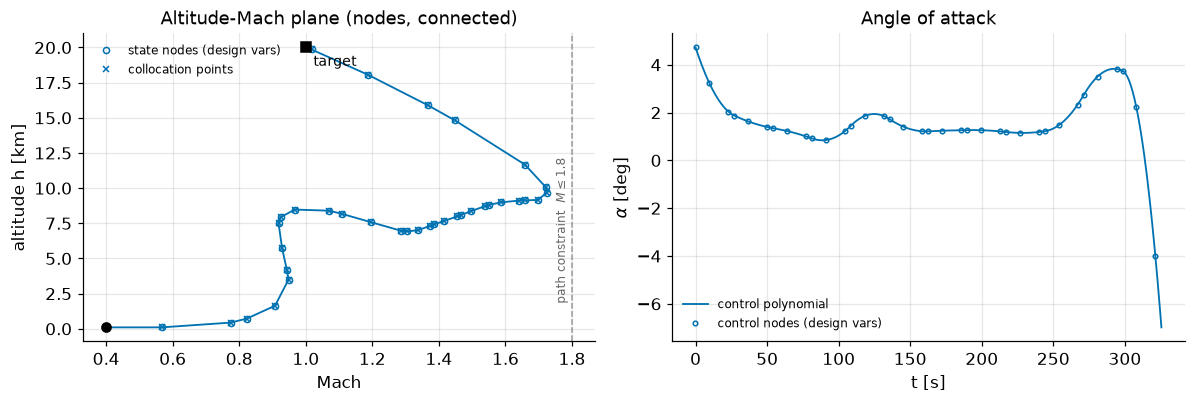

In [24]:
mtc = {k: p_mtc.get_val(f'phase0.timeseries.{k}')[:, 0]
       for k in ('time', 'h', 'alpha', 'mach')}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
gd = p_mtc.model.phase0.options['transcription'].grid_data
i_state, i_col = gd.subset_node_indices['state_input'], gd.subset_node_indices['col']
ax1.plot(mtc['mach'], mtc['h'] / 1e3, '-', lw=1.2, color=COLORS['dymos'])
ax1.plot(mtc['mach'][i_state], mtc['h'][i_state] / 1e3, 'o', ms=4, mfc='none',
         color=COLORS['dymos'], label='state nodes (design vars)')
ax1.plot(mtc['mach'][i_col], mtc['h'][i_col] / 1e3, 'x', ms=4, mew=1.0,
         color=COLORS['dymos'], label='collocation points')
ax1.axvline(1.8, color='0.6', ls='--', lw=1)
ax1.text(1.79, 2.0, 'path constraint  $M \\leq 1.8$', rotation=90,
         fontsize=8, color='0.4', ha='right')
ax1.plot(mtc['mach'][0], mtc['h'][0] / 1e3, 'o', color='k')
ax1.plot(1.0, 20, 's', color='k')
ax1.annotate('target', (1.0, 20), xytext=(5, -12), textcoords='offset points', fontsize=9)
ax1.set_xlabel('Mach'); ax1.set_ylabel('altitude h [km]')
ax1.set_title('Altitude-Mach plane (nodes, connected)'); ax1.legend(fontsize=8, loc='upper left')
T_a, U_a, t_a, u_a = dense_control(p_mtc, p_mtc.model.phase0, 'alpha')
ax2.plot(T_a, U_a, lw=1.2, color=COLORS['dymos'], label='control polynomial')
ax2.plot(t_a, u_a, 'o', ms=3, mfc='none', color=COLORS['dymos'],
         label='control nodes (design vars)')
ax2.set_xlabel('t [s]'); ax2.set_ylabel(r'$\alpha$ [deg]')
ax2.set_title('Angle of attack'); ax2.legend(fontsize=8)
fig.tight_layout()

The same Rutowski energy climb as in notebook 02 (subsonic climb, dive
through the transonic drag rise, supersonic acceleration along the Mach
limit, zoom climb to the target), and the same final time to a hundredth of
a second, in a fraction of the wall time. The NLP is larger, since the
segment-interior states are now unknowns rather than the result of a nested
solve, but each evaluation is one pass through the ODE at the nodes instead
of twelve Newton iterations to convergence.

---
## 7. Takeaways

| | Single shooting | Multiple shooting | Collocation |
|---|---|---|---|
| State variables | none | arc initial states | transcription-dependent state nodes |
| Dynamics enforced by | explicit integration | per-arc integration | defect constraints |
| Total Jacobian | boundary-constraint rows touch every variable | staircase blocks | sparse, banded |
| Cost per iteration | full propagation plus an augmented sensitivity system | shorter per-arc propagations plus sensitivities | ODE evaluated at every node, so it grows with segments times order |

1. **Collocation = polynomials + defects.** States and controls are nodal
   design variables, the dynamics are algebraic constraints at the
   collocation points, and terminal conditions are bounds. Nothing is
   integrated during the solve, so the guess need not be a trajectory.
2. **A zero defect pins the slope, not the state.** Between the collocation
   points the polynomial drifts from the true trajectory and the control can
   leave its bounds, and a coarse grid returns an optimistic objective. The
   grid sets the size of that error; the integration check and the
   per-segment error estimate measure it.
3. **Sparsity is the payoff.** Every defect touches one segment, so the
   Jacobian is banded and cheap; the SSTO and the climb solve several times
   faster than in Lecture 9 even with a dense SQP solver.
4. **Refinement localizes a discontinuity's error but cannot remove it.**
   Splitting the segment that contains the switch beats raising its order.
   A genuine discontinuity needs structure, multi-phase (Lecture 9) or the
   optimality conditions (Lecture 11).